# Data Analysis project
## Spotify songs Dataset

### EHRHART Elsa, SLISSE Paul, STAUB Guillaume, HOSSEINI Arman

### 0. Librairies

In [43]:
library(lubridate)
library(dplyr)
library(tidyr)
library(ggplot2)
library(VGAM)
library(GGally)
library(corrplot)
library(caret)
library("FactoMineR")
library("gridExtra")
library("factoextra")
library(reshape2)
library(MASS)
library(effectsize)
library(gplots)
library(graphics)
library(ggpubr)
library(NMF)
library(scales)
library(seriation)
library(stringr)
library(pheatmap)

### I.Nettoyage et exploration du dataset
#### Importation et nettoyage des données 
Dans ce projet, nous allons analyser un jeu de données contenant plusieurs informations sur des chansons écoutées sur Spotify.  
Pour chaque chanson, nous avons les variables suivantes :
- track_id
- track_name
- track_artist
- track_popularity : une note entre 0 et 100
- track_album_id : l'identifiant de l'album de la musique
- track_album_name
- track_album_release_date
- playlist_name
- playlist_genre : genre de la playlist dans laquelle est la musique
- playlist_subgenre : sous-genre de la playlist dans laquelle est la musique
- danceability : flottant entre 0 et 1 pour quantifier si la musique est dansable, sur la base de critères tels que le tempo, la stabilité du rythme, la force des battements et la régularité générale.
- energy : flottant entre 0 et 1 représentant une mesure perceptuelle de l'intensité et de l'activité
- key : estimation de la tonalité du morceau, 0=C, 1=C#, 2=D ... -1=aucune tonalité détectée
- loudness :intensité sonore en moyenne d'une musique en décibels (dB)
- mode : modalité d'une musique : majeur = 1, mineur = 0
- speechiness : flottant entre 0 et 1 indiquant la présence de paroles dans une piste >2/3 : presque uniquement des paroles, 1/3< <2/3 : contient à la fois de la musique et de la parole, <1/3 : pistes musicales et non parlantes
- acousticness : flottant entre 0 et 1 décrivant si la chanson est acoustique,on entend par acoustique que le fond sonore (en opposition au chant) provient de vrais instrument et n'est pas produit numériquement
- instrumentalness : flottant entre 0 et 1 représentant si la piste est plus vocale : proche de 0 ou instrumentale : proche de 1
- liveness : flottant entre 0 et 1 détectant la présence ou non d'un public. Au dessus de 0.8 la piste est probablement un live d'un concert
- valence : flotteur entre 0 et 1 mesurant la positivité d'une chanson (proche de 1)
- tempo : tempo en battements par minute (BPM)
- duration_ms: durée de la musique en millisecondes

In [44]:
path <- "spotify_songs.csv"
song <- read.csv(path, header = TRUE)
# Premières lignes du jeu de données
head(song)

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,⋯,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxury Remix,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury Remix],2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,6,-2.634,1,0.0583,0.1020,0.00e+00,0.0653,0.518,122.036,194754
2,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,11,-4.969,1,0.0373,0.0724,4.21e-03,0.3570,0.693,99.972,162600
3,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,1,-3.432,0,0.0742,0.0794,2.33e-05,0.1100,0.613,124.008,176616
4,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,7,-3.778,1,0.1020,0.0287,9.43e-06,0.2040,0.277,121.956,169093
5,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,1,-4.672,1,0.0359,0.0803,0.00e+00,0.0833,0.725,123.976,189052
6,7fvUMiyapMsRRxr07cU8Ef,Beautiful People (feat. Khalid) - Jack Wins Remix,Ed Sheeran,67,2yiy9cd2QktrNvWC2EUi0k,Beautiful People (feat. Khalid) [Jack Wins Remix],2019-07-11,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,8,-5.385,1,0.1270,0.0799,0.00e+00,0.1430,0.585,124.982,163049


On va décomposer la variable de date en jour mois année puis uniquement récupérer le mois et l'année. Ici, si le mois n'est pas présent, il est mit par défaut à 1, on ne va pas s'intéresser trop à cette variable donc cela ne pose pas de problème.

In [45]:
formats <- c("Ymd", "Ym", "Y")

# Parse les dates en tenant compte des différents formats
song$parsed_date <- parse_date_time(song$track_album_release_date, orders = formats)

# Extraire mois et année
song$month <- month(song$parsed_date, label = FALSE) # label=TRUE pour Jan, Feb...
song$year <- year(song$parsed_date)

# Supprimer l'ancienne colonne
song <- subset(song, select = -track_album_release_date)

# (optionnel) supprimer la colonne parsed_date si plus utile
song <- subset(song, select = -parsed_date)


On va tout d'abord regarder si on a des duplicatas dans notre dataset en utilisant le track_id.

In [46]:
sum(duplicated(song$track_id))
#song<-song[!duplicated(song$track_id),]

[1] 4477

On voit qu'on a beaucoup de duplicatas. En cherchant dans le dataset, on a découvert que ces duplicatas sont enfait dans différentes playlists qui n'ont pas le même genre. On en déduit que l'extraction des données a été faites via les playlists et c'est donc pour cela qu'on a des duplicatas. Nous allons garder qu'une seule occurence de chaque musique. Pour choisir laquelle, nous allons garder une occurence dont le genre (puis le sous-genre) est le mode des différents genres de la musique (différents genres des différentes occurences de la musique). Exemple: Dancing Queen apparait 3 fois, 2 fois avec pop et une fois avec latin, on va garder une occurence de pop.
On en profite également pour stocker dans une nouvelle variable le nombre de playlist où apparait la musique. Cependant, une musique présente dans de nombreuses playlists implique que cette musique doit être plutôt écouté et pour ne pas perdre non plus toutes l'information, on va garder pour chaque musique son nombre d'apparitions dans le dataset.

Ce nettoyage particulier est réalisé notamment pour les analyses factorielles afin de ne pas trop les biaiser avec une musique apparaissant plus que d'autres. Pour certaines méthodes, notamment la NMF, on va utiliser le dataset complet pour obtenir de meilleurs résultats.

In [47]:
song <- song %>%
  group_by(track_id) %>%
  add_count(name = "playlist_appearance_count") %>%
  ungroup() %>%

  # Ensuite ton pipeline :
  group_by(track_id, playlist_genre) %>%
  add_count(name = "genre_count") %>%
  group_by(track_id) %>%
  arrange(desc(genre_count), .by_group = TRUE) %>%
  slice(1) %>%
  ungroup() %>%
  dplyr::select(-genre_count) %>%

  group_by(track_id, playlist_subgenre) %>%
  add_count(name = "subgenre_count") %>%
  group_by(track_id) %>%
  arrange(desc(subgenre_count), .by_group = TRUE) %>%
  slice(1) %>%
  ungroup() %>%
  dplyr::select(-subgenre_count)
sum(duplicated(song$track_id))

[1] 0

Nous allons maintenant supprimer les variables inutiles à l'analyse comme le `track_id` (un identifiant différent par musique) qui ne sera d'aucune utilité pour notre analyse car l'information est déjà contenue dans la variable `track_name` que nous n'utiliserons que pour labelliser.
De même, on va supprimer `track_album_id`,`playlist_id`.

On va également modifier la variable de durée en la passant en secondes au lieu de millisecondes pour avoir des valeurs plus parlantes.

In [48]:
song<-subset(song,select=-track_id)
song<-subset(song,select=-track_album_id)
song<-subset(song,select=-playlist_id)

colnames(song)[which(colnames(song)=="duration_ms")]<-"duration_s"
song[,"duration_s"]<-song[,"duration_s"]/1000

head(song)

track_name,track_artist,track_popularity,track_album_name,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,⋯,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s,month,year,playlist_appearance_count
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Pangarap,Barbie's Cradle,41,Trip,Pinoy Classic Rock,rock,classic rock,0.682,0.401,2,⋯,0.0236,0.279000,0.011700,0.0887,0.566,97.091,235.440,1,2001,1
The Others,RIKA,15,The Others,Groovy // Funky // Neo-Soul,r&b,neo soul,0.582,0.704,5,⋯,0.0347,0.065100,0.000000,0.2120,0.698,150.863,197.286,1,2018,1
I Feel Alive,Steady Rollin,28,Love & Loss,Hard Rock Workout,rock,hard rock,0.303,0.880,9,⋯,0.0442,0.011700,0.009940,0.3470,0.404,135.225,373.512,11,2017,1
Liquid Blue,The.madpix.project,24,Liquid Blue,Electropop - Pop,pop,electropop,0.659,0.794,10,⋯,0.0540,0.000761,0.132000,0.3220,0.852,128.041,228.565,8,2015,1
Fever,YOSA & TAAR,38,Fever,Best of 2019 Dance Pop: Japan,pop,dance pop,0.662,0.838,1,⋯,0.0499,0.114000,0.000697,0.0881,0.496,129.884,236.308,11,2018,1
No Me Acuerdo,Thalía,12,No Me Acuerdo,latin hip hop,latin,latin hip hop,0.836,0.799,7,⋯,0.0873,0.187000,0.000000,0.0920,0.772,94.033,217.653,6,2018,1


On modifie les variables qualitatives en facteurs. On en utilisera certaines pour les analyses, d'autres ne seront utilisés que pour labelliser.

In [49]:
song$playlist_genre<-as.factor(song$playlist_genre)
song$playlist_subgenre<-as.factor(song$playlist_subgenre)
song$mode<-as.factor(song$mode)
song$track_artist<-as.factor(song$track_artist)
song$track_album_name<-as.factor(song$track_album_name)
song$playlist_name<-as.factor(song$playlist_name)
song$key<-as.factor(song$key)
head(song)

track_name,track_artist,track_popularity,track_album_name,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,⋯,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s,month,year,playlist_appearance_count
<chr>,<fct>,<int>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<fct>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Pangarap,Barbie's Cradle,41,Trip,Pinoy Classic Rock,rock,classic rock,0.682,0.401,2,⋯,0.0236,0.279000,0.011700,0.0887,0.566,97.091,235.440,1,2001,1
The Others,RIKA,15,The Others,Groovy // Funky // Neo-Soul,r&b,neo soul,0.582,0.704,5,⋯,0.0347,0.065100,0.000000,0.2120,0.698,150.863,197.286,1,2018,1
I Feel Alive,Steady Rollin,28,Love & Loss,Hard Rock Workout,rock,hard rock,0.303,0.880,9,⋯,0.0442,0.011700,0.009940,0.3470,0.404,135.225,373.512,11,2017,1
Liquid Blue,The.madpix.project,24,Liquid Blue,Electropop - Pop,pop,electropop,0.659,0.794,10,⋯,0.0540,0.000761,0.132000,0.3220,0.852,128.041,228.565,8,2015,1
Fever,YOSA & TAAR,38,Fever,Best of 2019 Dance Pop: Japan,pop,dance pop,0.662,0.838,1,⋯,0.0499,0.114000,0.000697,0.0881,0.496,129.884,236.308,11,2018,1
No Me Acuerdo,Thalía,12,No Me Acuerdo,latin hip hop,latin,latin hip hop,0.836,0.799,7,⋯,0.0873,0.187000,0.000000,0.0920,0.772,94.033,217.653,6,2018,1


In [50]:
colSums(is.na(song))

track_name              track_artist          track_popularity 
                        4                         4                         0 
         track_album_name             playlist_name            playlist_genre 
                        4                         0                         0 
        playlist_subgenre              danceability                    energy 
                        0                         0                         0 
                      key                  loudness                      mode 
                        0                         0                         0 
              speechiness              acousticness          instrumentalness 
                        0                         0                         0 
                 liveness                   valence                     tempo 
                        0                         0                         0 
               duration_s                     month                      year 
                        0                         0                         0 
playlist_appearance_count 
                        0

Comme les NA pour le mois on été géré en les remplacant par une valeur par défaut, on a que quelques NA pour les variables `track_artist` et `track_album_name`. On va les retirer pour éviter des problèmes d'éxécution lors des différentes analyses. On ne perd que très peu d'information (4 valeurs sur tous les datasets).

In [51]:
song<-song %>% drop_na(track_artist)

In [52]:
colSums(is.na(song))

track_name              track_artist          track_popularity 
                        0                         0                         0 
         track_album_name             playlist_name            playlist_genre 
                        0                         0                         0 
        playlist_subgenre              danceability                    energy 
                        0                         0                         0 
                      key                  loudness                      mode 
                        0                         0                         0 
              speechiness              acousticness          instrumentalness 
                        0                         0                         0 
                 liveness                   valence                     tempo 
                        0                         0                         0 
               duration_s                     month                      year 
                        0                         0                         0 
playlist_appearance_count 
                        0

On voit qu'on a bien supprimé tous les individus sans track_artist et track_album_name.

In [53]:
nb_mv_key <- 0

for (i in 1:nrow(song)) {
  if (song$key[i] == -1) {
    nb_mv_key <- nb_mv_key + 1
  }
}

cat("Key - Number of missing values :", nb_mv_key, "\n")

Key - Number of missing values : 0 


Il n'y a aucune valeur manquante pour la clé, contrairement à ce qu'on aurait pu supposer avec le descriptif du jeu de données. Cela fait un problème de moins à régler.

On va supprimer les musiques qui durent moins de 30 secondes car elles sont trop courtes pour qu'on puisse vraiment les juger.

In [54]:
song<-song[!song$duration_s<30,]

On va créer une variable period qui représente la décennie de sortie de la musique.

In [55]:
song <- song %>%
  mutate(
    period = case_when(
      is.na(year)              ~ "2010s",
      year > 2010              ~ "2010s",
      year > 2000              ~ "2000s",
      year > 1990              ~ "1990s",
      year > 1980              ~ "1980s",
      year > 1970              ~ "1970s",
      year > 1960              ~ "1960s",
      TRUE                     ~ "1950s"
    ))
song$month<-as.factor(song$month)
song$year<-as.factor(song$year)
song$period <- as.factor(song$period)

#### Exploration des données

In [14]:
histo_genre <- ggplot(song,aes(x=playlist_genre))+
  geom_histogram(stat="count")+
  labs(title = "Distribution des genres des musiques")

histo_year <- ggplot(song,aes(x=year))+
    geom_histogram(stat="count")+
    labs(title = "Distribution des années de sortie des musiques")+
    scale_x_discrete(breaks = levels(factor(song$year))[seq(1, length(levels(factor(song$year))), by = 10)])

histo_month <- ggplot(song,aes(x=month))+
    geom_histogram(stat="count",fill='blue')+
    labs(title = "Distribution des mois de sortie des musiques")

histo_popularity <- ggplot(song,aes(x=track_popularity))+
    geom_histogram(stat="count")+
    labs(title = "Distribution des popularités des musiques")

histo_danceability <- ggplot(song,aes(x=danceability))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la danceabilité des musiques")

histo_energy <- ggplot(song,aes(x=energy))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de l'energie des musiques")

histo_key <- ggplot(song,aes(x=key))+
    geom_histogram(stat='count')+
    labs(title = "Distribution de la clé des musiques")

histo_loudness <- ggplot(song,aes(x=loudness))+
    geom_histogram(bins=50)+
  labs(title = "Distribution de la force sonore des musiques")

histo_mode  <- ggplot(song,aes(x=mode))+
    geom_histogram(bins=50,stat='count')+
    labs(title = "Distribution de du mode des musiques")

histo_speechiness <- ggplot(song,aes(x=speechiness))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la vocabilité des musiques")

histo_instrumentalness <- ggplot(song,aes(x=instrumentalness))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de l'intrumentabilité des musiques")

histo_liveness <- ggplot(song,aes(x=liveness))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la liveness des musiques")

histo_valence <- ggplot(song,aes(x=valence))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la valence des musiques")

histo_tempo <- ggplot(song,aes(x=tempo))+
    geom_histogram(bins=50)+
    labs(title = "Distribution du tempo des musiques")

histo_duration_s <- ggplot(song,aes(x=duration_s))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la durée des musiques")

histo_nbplaylist  <- ggplot(song,aes(x=playlist_appearance_count))+
    geom_histogram()+
    labs(title = "Distribution du nombre d'apparition dans les playlists")
histo_period <- ggplot(song,aes(x=period))+
    geom_histogram(stat='count')+
    labs(title ="Distribution des décennies des musiques")

Warning message in geom_histogram(stat = "count"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"
Warning message in geom_histogram(stat = "count"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"
Warning message in geom_histogram(stat = "count", fill = "blue"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"
Warning message in geom_histogram(stat = "count"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"
Warning message in geom_histogram(stat = "count"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"
Warning message in geom_histogram(bins = 50, stat = "count"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"
Warning message in geom_histogram(stat = "count"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


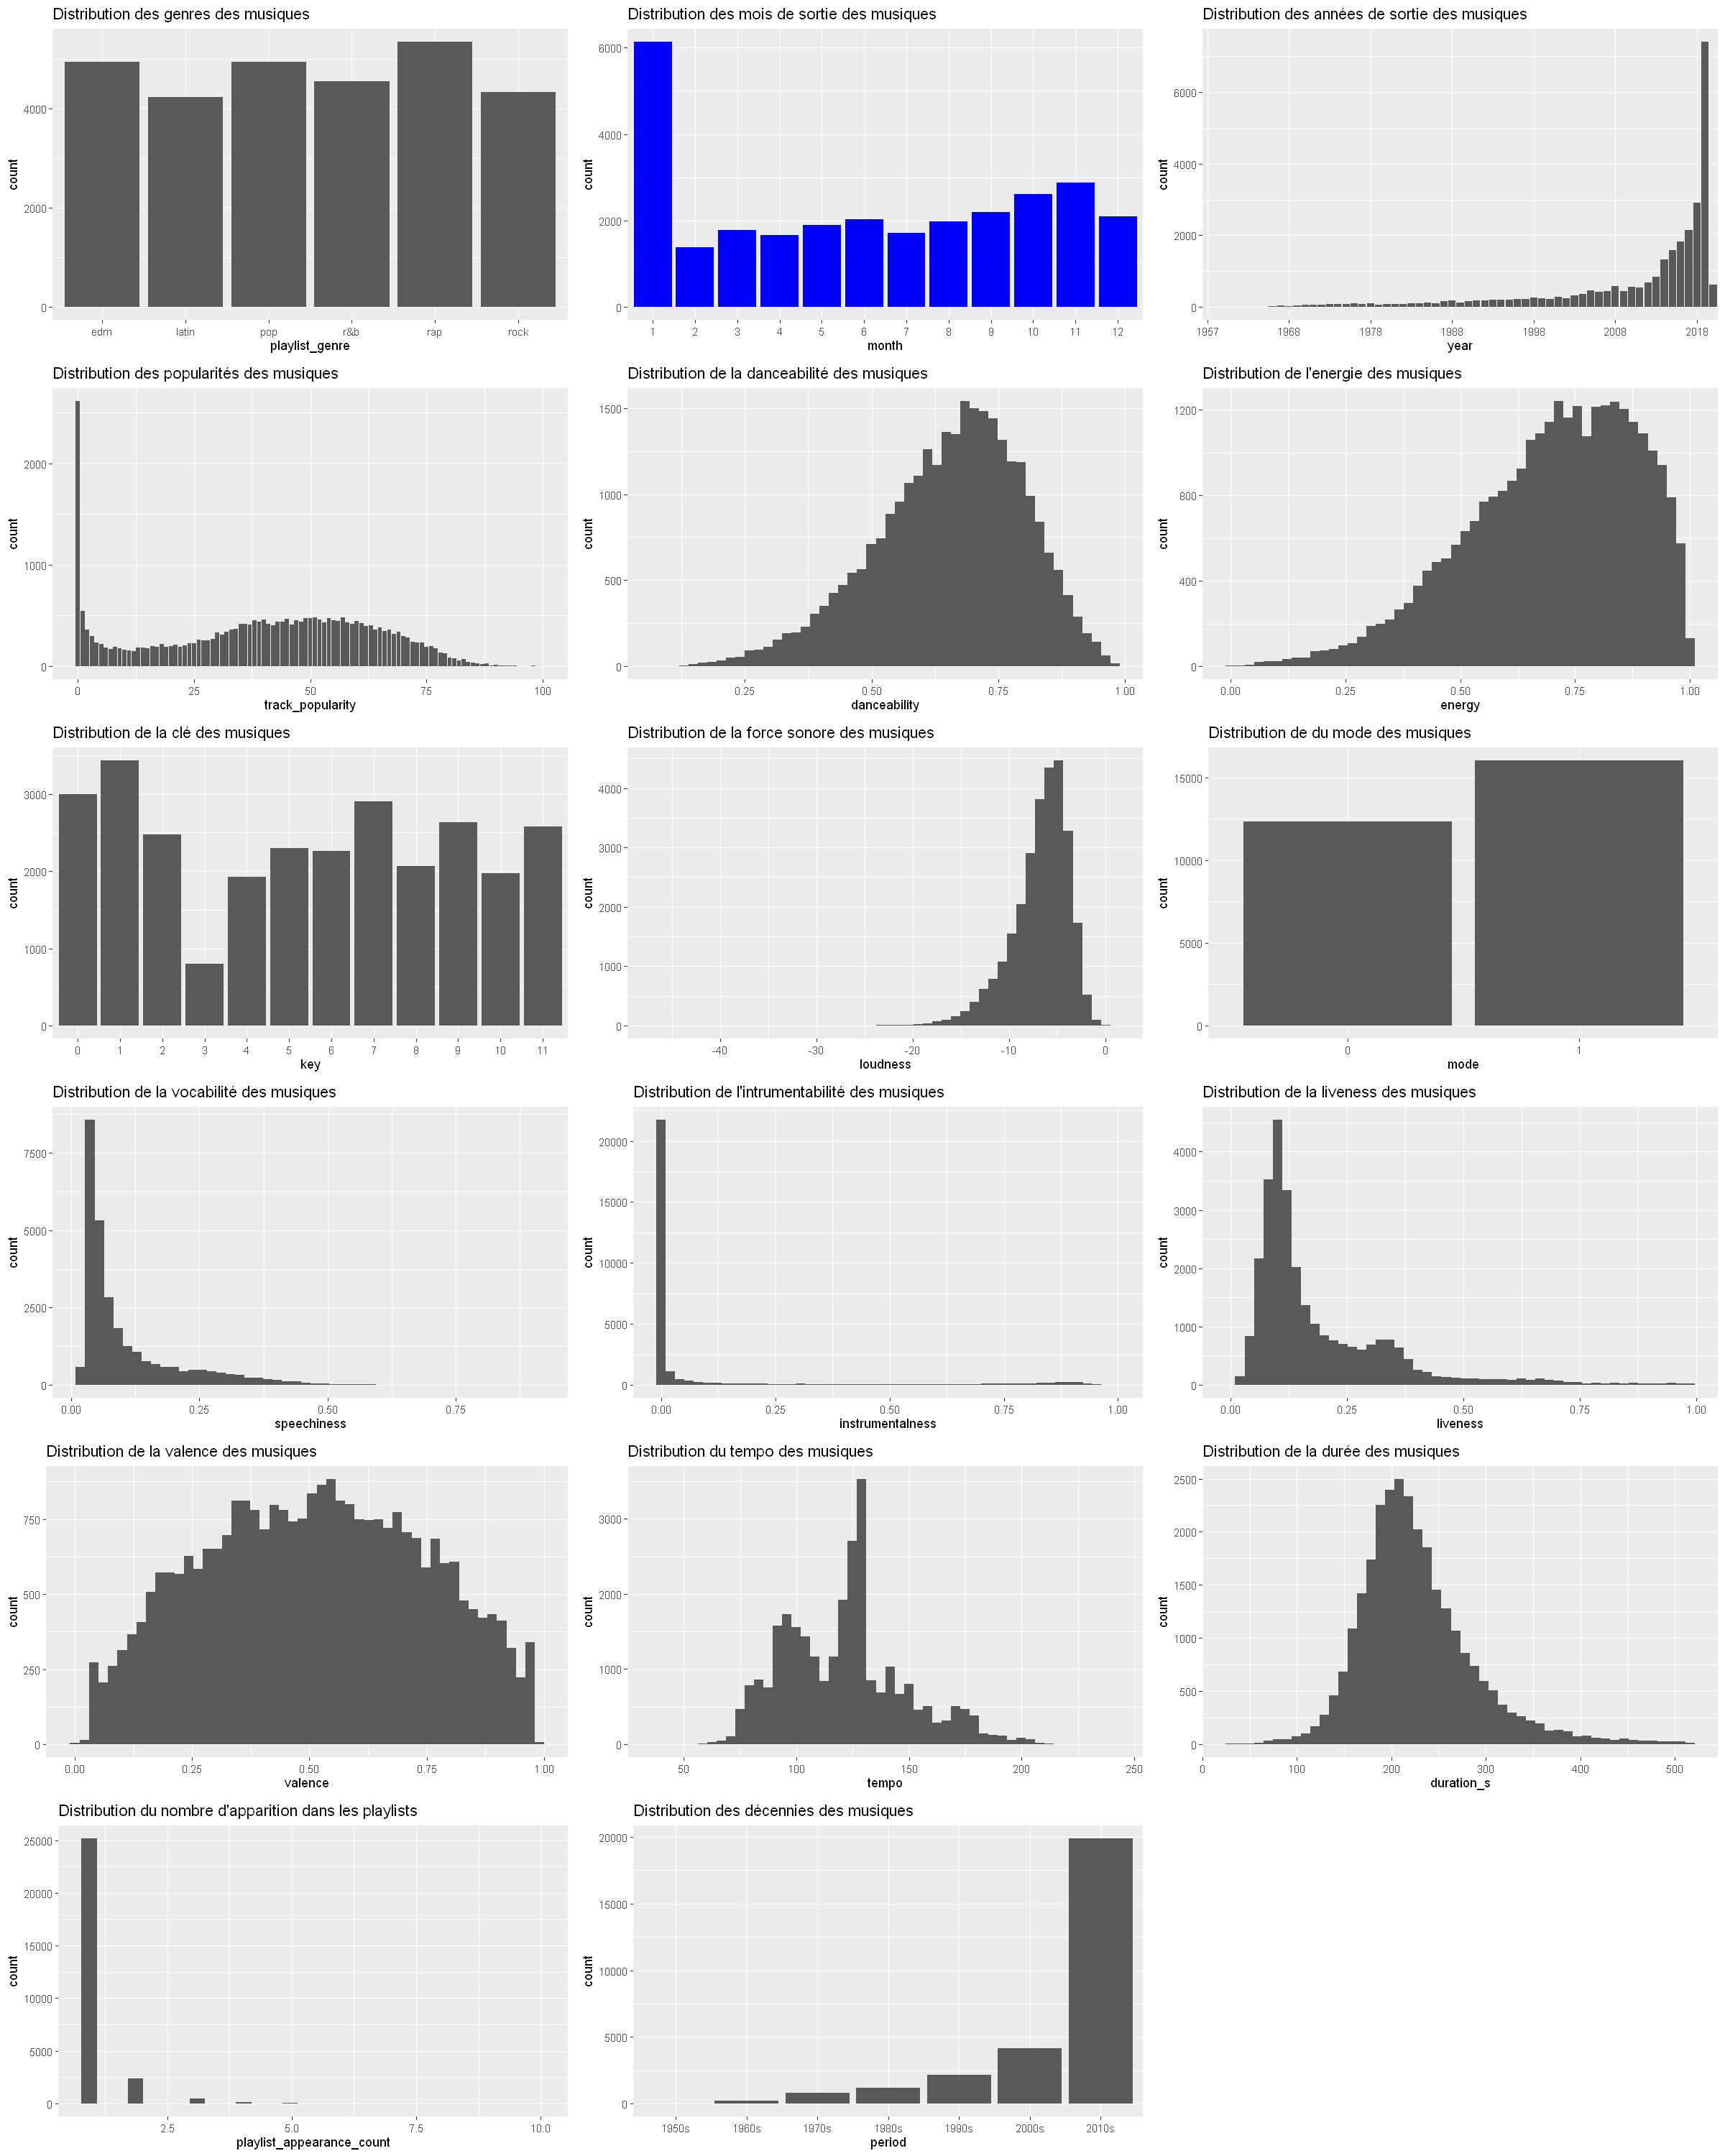

In [15]:
options(repr.plot.width=20, repr.plot.height=25)
grid.arrange(histo_genre,histo_month,histo_year, histo_popularity,histo_danceability,histo_energy,histo_key,histo_loudness,histo_mode,histo_speechiness, histo_instrumentalness, histo_liveness,histo_valence,histo_tempo,histo_duration_s,histo_nbplaylist,histo_period, ncol=3)

On observe qu'on a beaucoup plus de musiques récentes notamment de la dernière décennie (2010-2020), ce qui ce comprend car c'est à ce moment qu'on émergé les plateformes de streaming comme Spotify et que le marché de la musique a explosé.

On a beaucoup de musique très peu populaire. La majorité des gens vont écouter des artistes connus mais comme il est assez aisé (comparé à avant) de publier une musique sur les plateformes de streaming, il y a beacoup d'artistes niches et donc de musiques très peu voir pas écouté donc avec une très faible popularité.

Assez surprenament, on a beaucoup moins de musiques avec la tonalité (D♯/E♭) que les autres tonalité, aucune explication pour cela.

On a dans notre jeu de données des musiques avec assez peu d'élocution (speechiness) et d'instrumentalité. On en déduit que ces mesures sont assez dures vis à vis des musiques. Il semble assez compliqué d'avoir une speechinness ou une instrumentalness assez élevé. On a une certaine contradiction avec la descprition du dataset qui nous a été donné car ces deux mesures devrait ce complémenter or on voit bien sur le graphe que ce n'est pas le cas. On peut avoir des musiques avec une speechiness et instrumentalness très faible ce qui correspond à une musique où il y a peu d'instrument/fond sonore et peu de paroles donc enfait des musiques vides.
Cela pourrait s'expliquer par le fait que Spotify ne considère pas des vocalises ou autres onomatopées comme paroles mais comme chant et ne le prend pas en compte dans le calcul de la speechiness.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwid

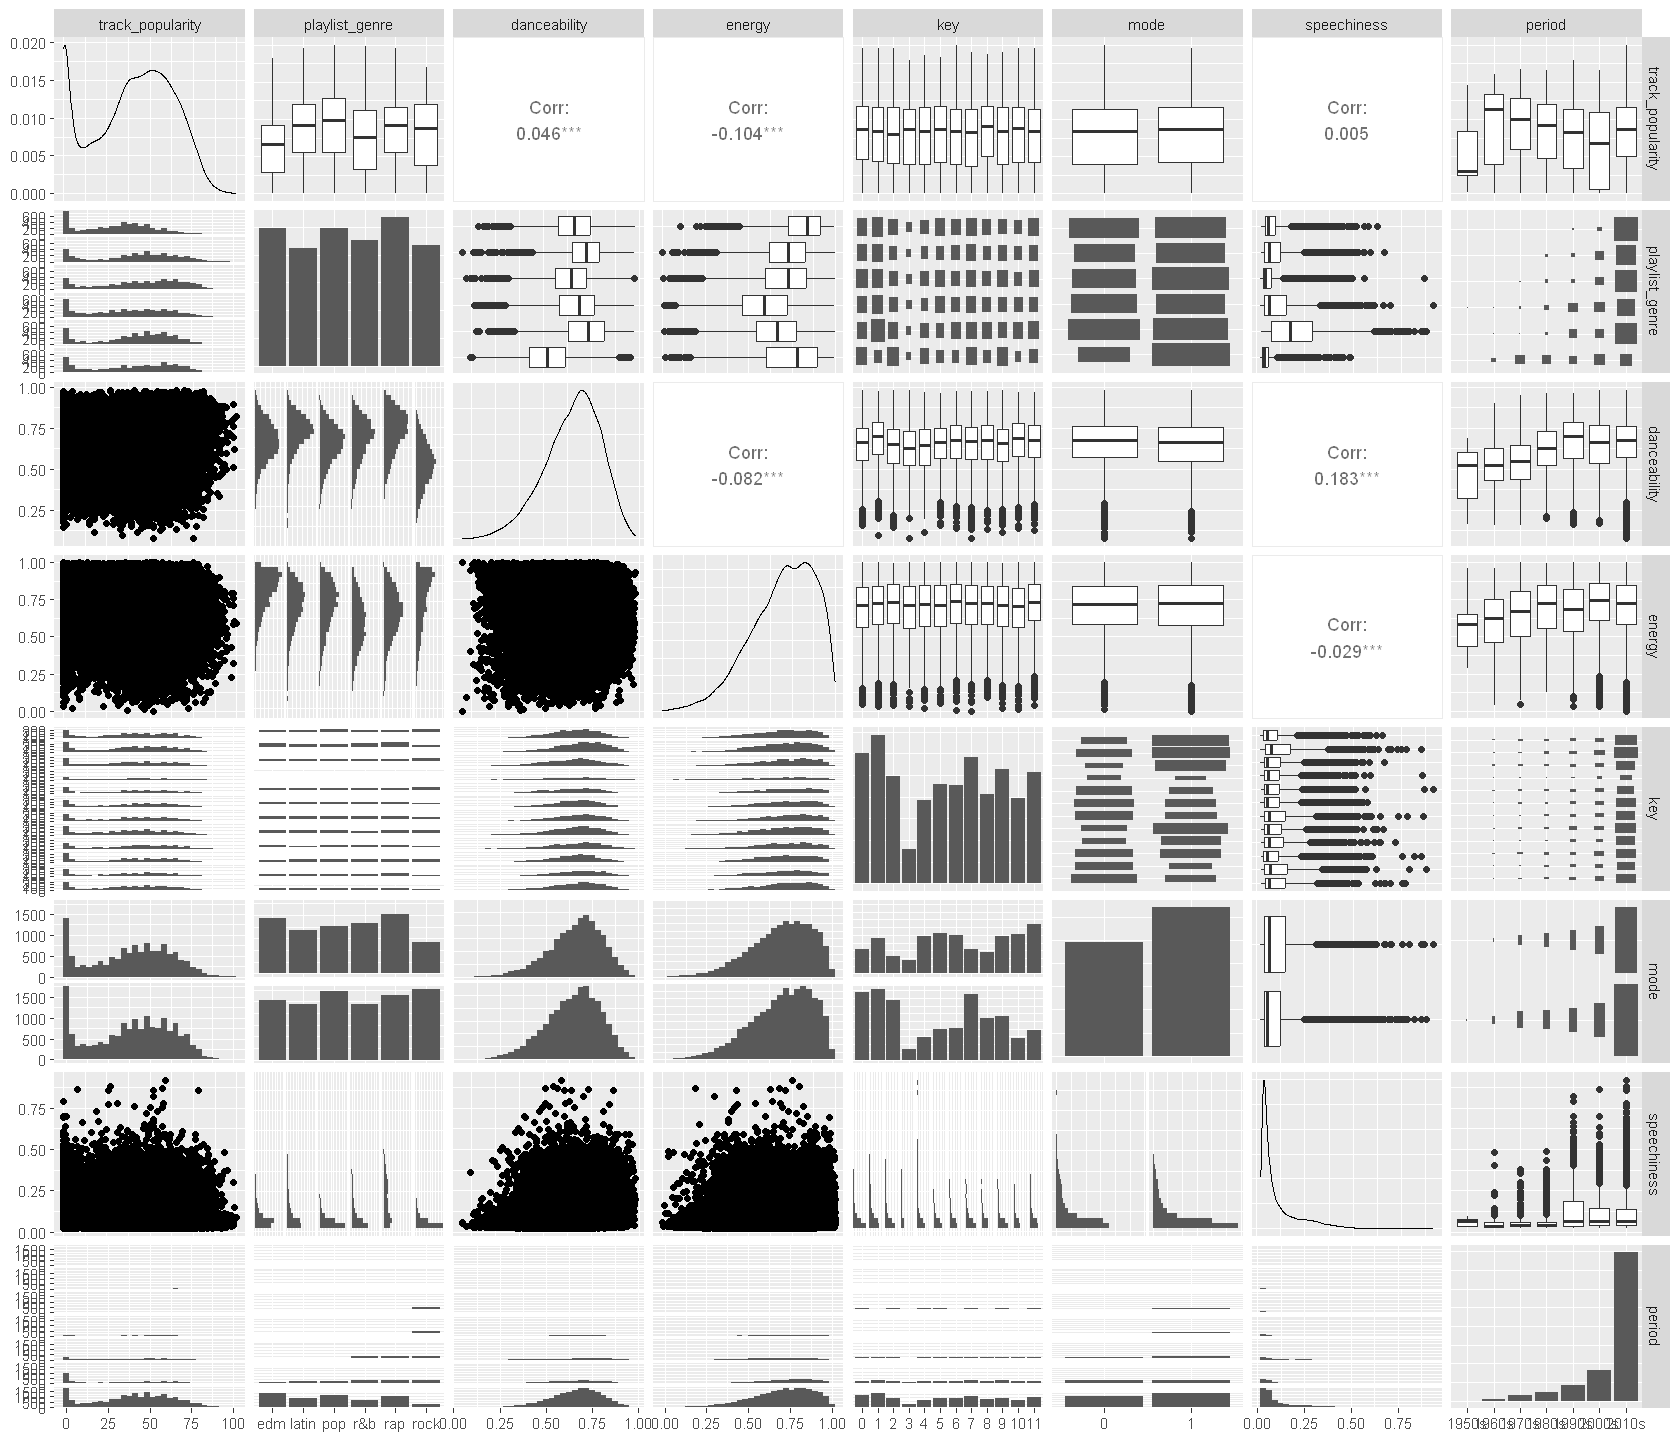

In [17]:
options(repr.plot.width=14,repr.plot.height=12)
ggpairs(song,columns=c(3,6,8,9,10,12,13, 23), cardinality_threshold = 15, progress = FALSE)

On constate que la pop est le genre le plus populaire en moyenne, mais la différence est faible. L'EDM est le genre le moins populaire.
On constate que les années 50 et 2000 sont les décennies les moins populaires.Le rap est le genre le plus dansant, le rock l'est moins. 
Comme on pouvait s'y attendre, l'edm est le genre le plus énergique. 
En mode mineur, les musiques ont tendance à avoir des clés plus aigues. On retrouve bien la définition du rap, qui se définit comme un genre avec beaucoup de paroles, de textes et moins de musiques, c'est le genre avec le plus de speechiness. On trouve également qu'on a plus de speechiness à partir des années 90. On retrouve donc là les débuts de l'ascencion du rap. De même, on trouve quand est-ce que les différents genres ont émergés (années 2000 pour latin et pop, années 90 pour rap et 80 pour r&b).

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwid

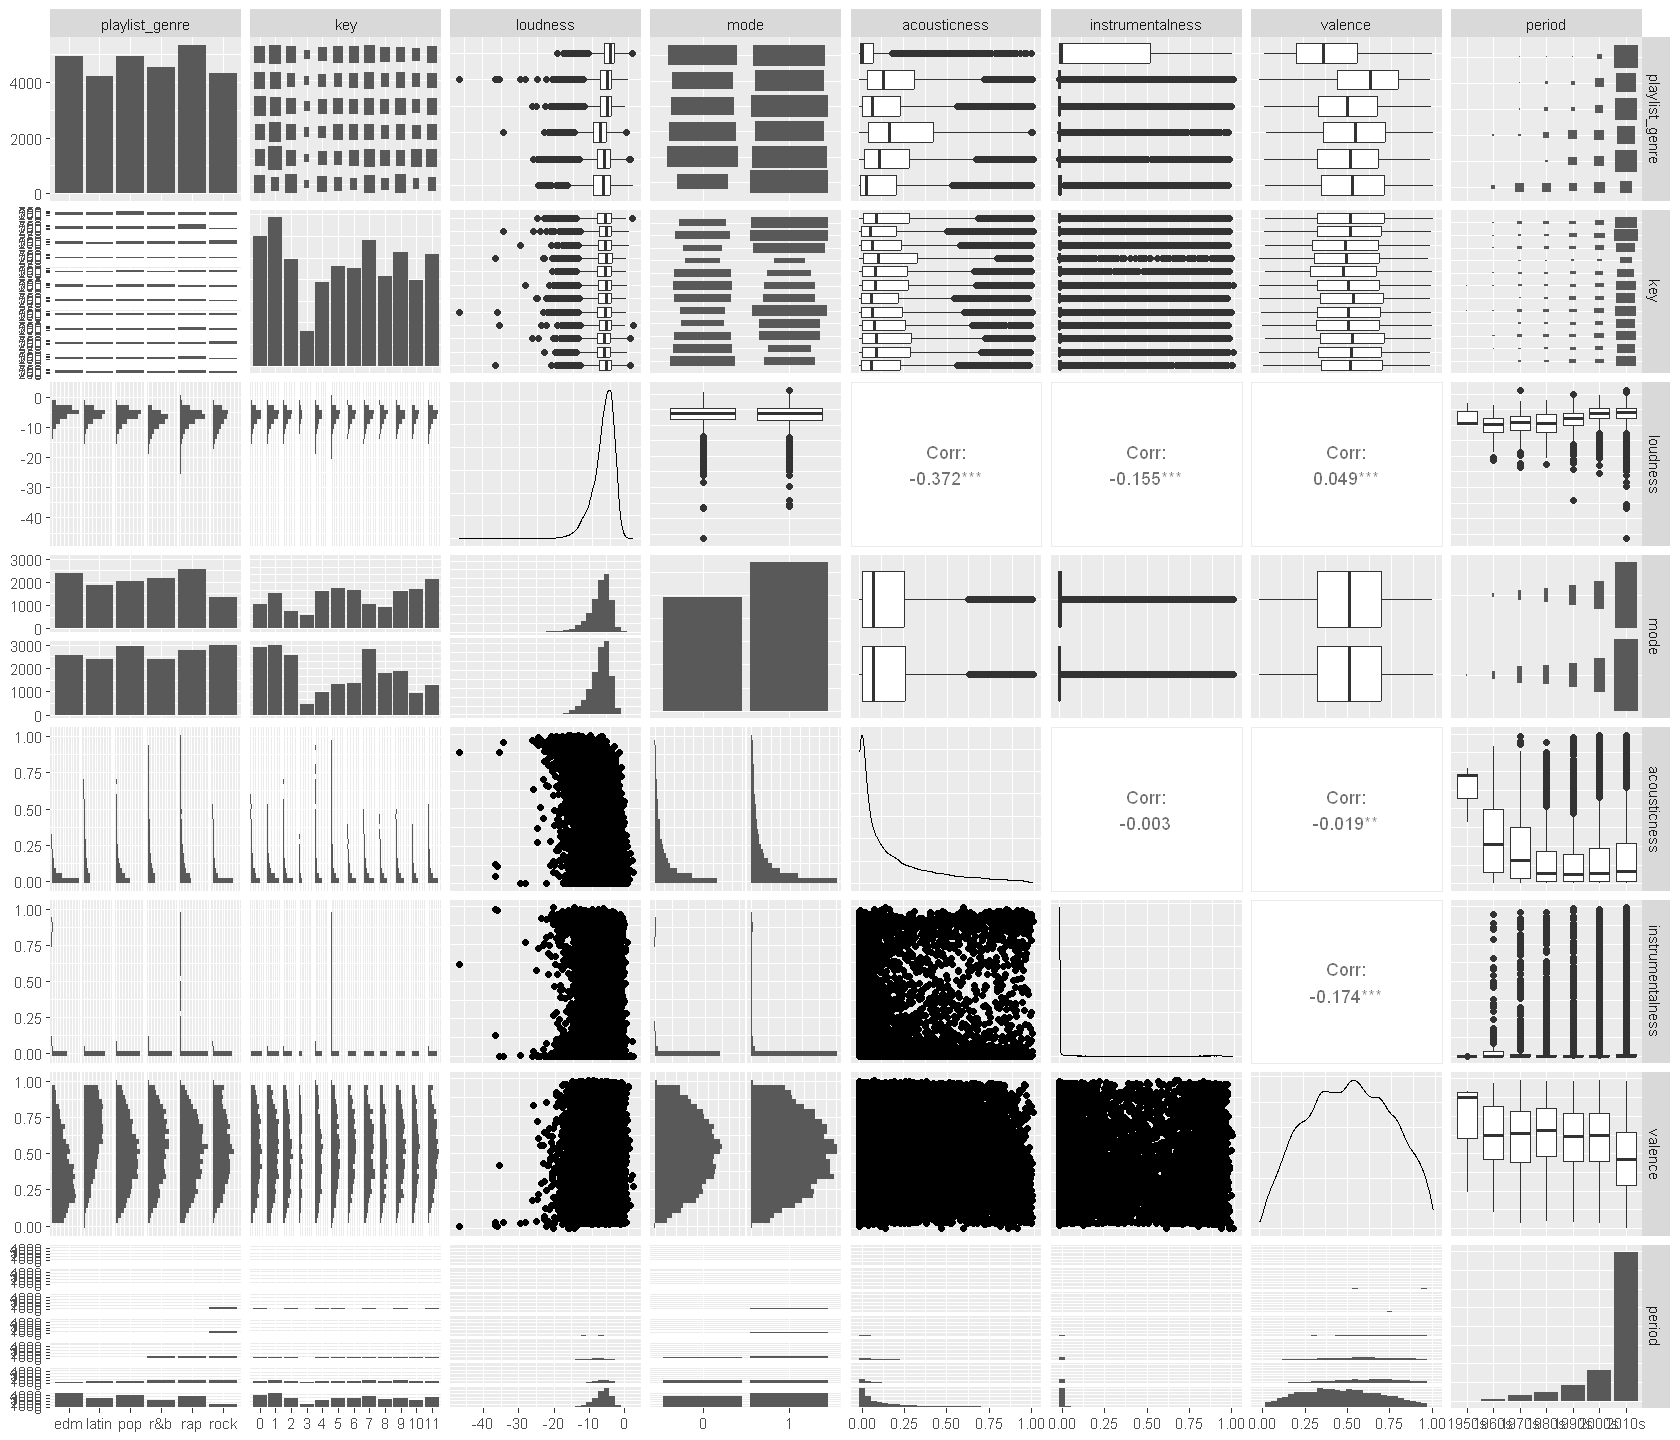

In [18]:
ggpairs(song,columns=c(6,10,11,12,14,15,17, 23), cardinality_threshold = 15, progress = FALSE)

Les musiques du genre edm ont tendance à avoir une intensité sonore plus élevé que les autres.
On observe que les musiques r&b ont tendance à avoir une meilleure acoustique et que les musiques des années 50,60 et 70 ont également tendance à avoir une meilleure acoustique. On rappelle que par acoustique, on entend que le fond sonore (en opposition au chant) provient de vrais instrument et n'est pas produit numériquement.
On pourrait se dire qu'il est assez innatendu que l'edm soit le genre le plus instrumental mais comme ici la définition d'instrumental est la proportion de fond sonore par rapport au chant (en contradiction avec speechiness), cela devient normal car dans le genre edm il y a beaucoup moins de paroles.
L'edm est le genre avec la valence la plus faible et est donc moins positif que les autres genres.On observe une tendance décroissante de la positivité des musiques avec la décennie. 

Pour les autres variables, il n'y a pas de liens évidents qui ressortent.

In [21]:
summary(song)

  track_name                           track_artist   track_popularity
 Length:28350       Queen                    :  130   Min.   :  0.00  
 Class :character   Martin Garrix            :   87   1st Qu.: 21.00  
 Mode  :character   Don Omar                 :   84   Median : 42.00  
                    David Guetta             :   81   Mean   : 39.34  
                    Dimitri Vegas & Like Mike:   68   3rd Qu.: 58.00  
                    Drake                    :   68   Max.   :100.00  
                    (Other)                  :27832                   
                    track_album_name            playlist_name   playlist_genre
 Greatest Hits              :  135   Indie Poptimism   :  293   edm  :4944    
 Ultimate Freestyle Mega Mix:   42   Permanent Wave    :  224   latin:4228    
 Gold                       :   34   Hard Rock Workout :  211   pop  :4947    
 Rock & Rios (Remastered)   :   29   Southern Hip Hop  :  173   r&b  :4544    
 Asian Dreamer              :   20   

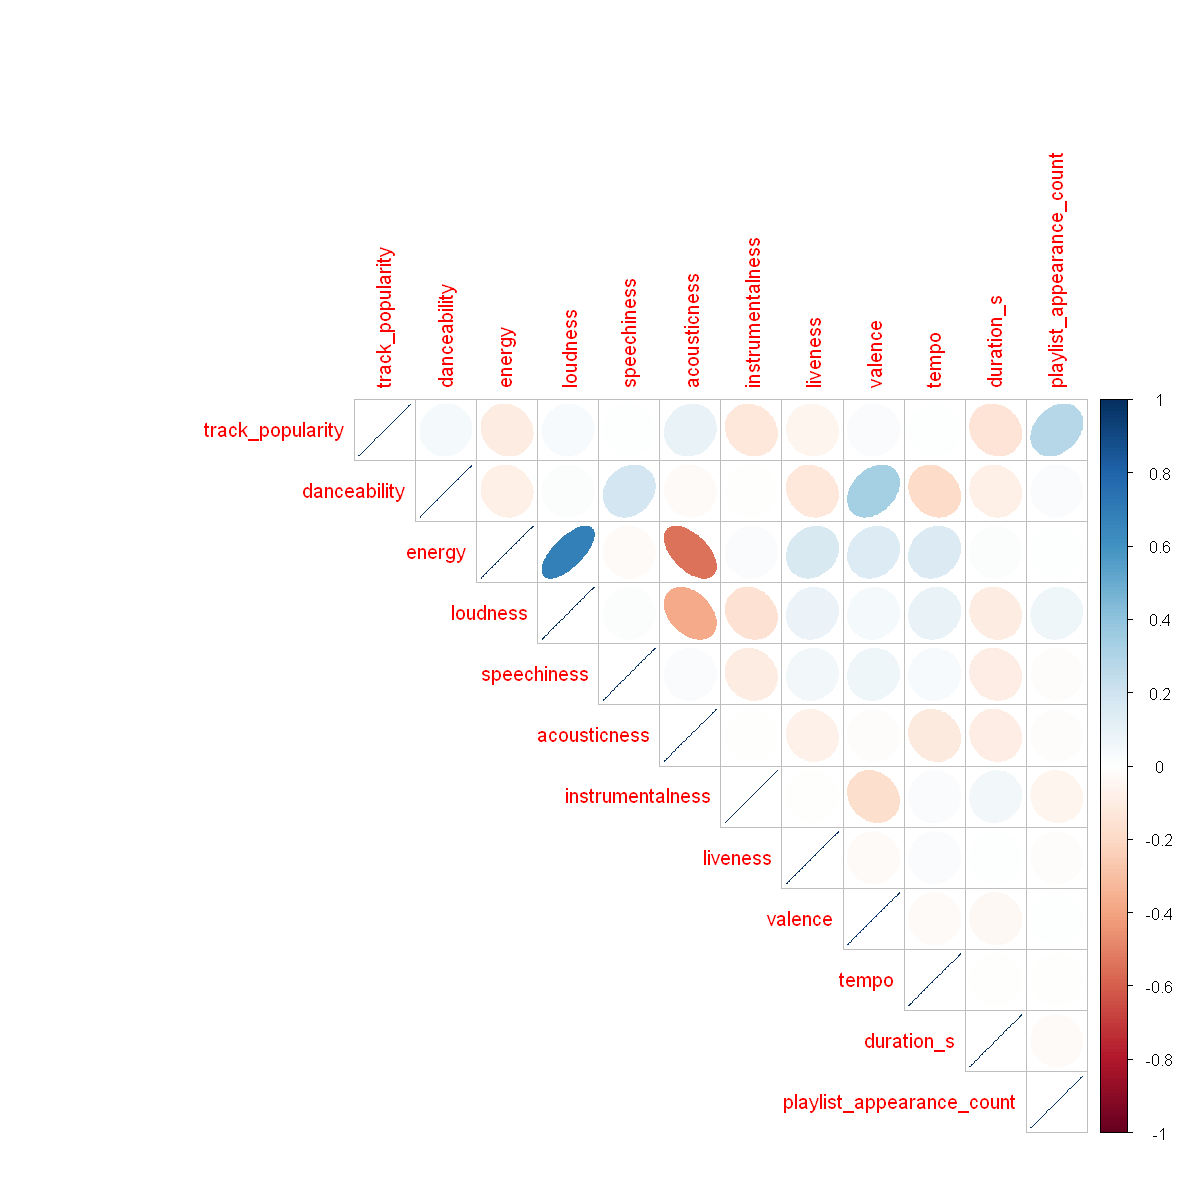

In [22]:
song_num <- song[,c(3,8,9,11,13:19,22)]
options(repr.plot.width=10, repr.plot.height=10)
corrplot(cor(song_num), method = "ellipse",type="upper")
#ggpairs(song, columns = c(2, 5, 7, 8, 9, 10, 11, 12,13,14,15,16,17,18,19), columnLabels = c("track_popularity", "playlist_genre", "danceability", "energy", "key", "loudness", "mode", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo", "duration_s", "month"))

L'énergie et l'intensité sonore sont fortement corrélées positivement.
L'énergie et l'acoustique sont négativement corrélées. L'intensité sonore et l'acoustique sont légèrement corrélées négativement. C'est compréhensible car lorsqu'une chanson devient plus forte, il devient souvent plus difficile de distinguer les différents instruments et sons.
L'aptitude à la danse et la valence sont légèrement corrélées positivement. Ainsi, une chanson sur laquelle il est plus facile de danser est plus susceptible d'inspirer un sentiment positif à ses auditeurs.
On observe également que la popularité et le nombre d'apparition dans les playlists sont moyennement positivement corrélés. On en déduit que d'apparaitre dans plusieurs playlists rend populaire mais la réciproque est fausse, une musique populaire n'est pas forcément dans plusieurs playlists.

On espère que ces corrélations vont nous permettre de réduire la dimension de notre jeu de données.

## ACP

In [58]:
suppressWarnings({
res.pca <- PCA(song,quali.sup=c(1,2,4:7,10,12,20:21,23),scale.unit=TRUE,ncp=8)
})

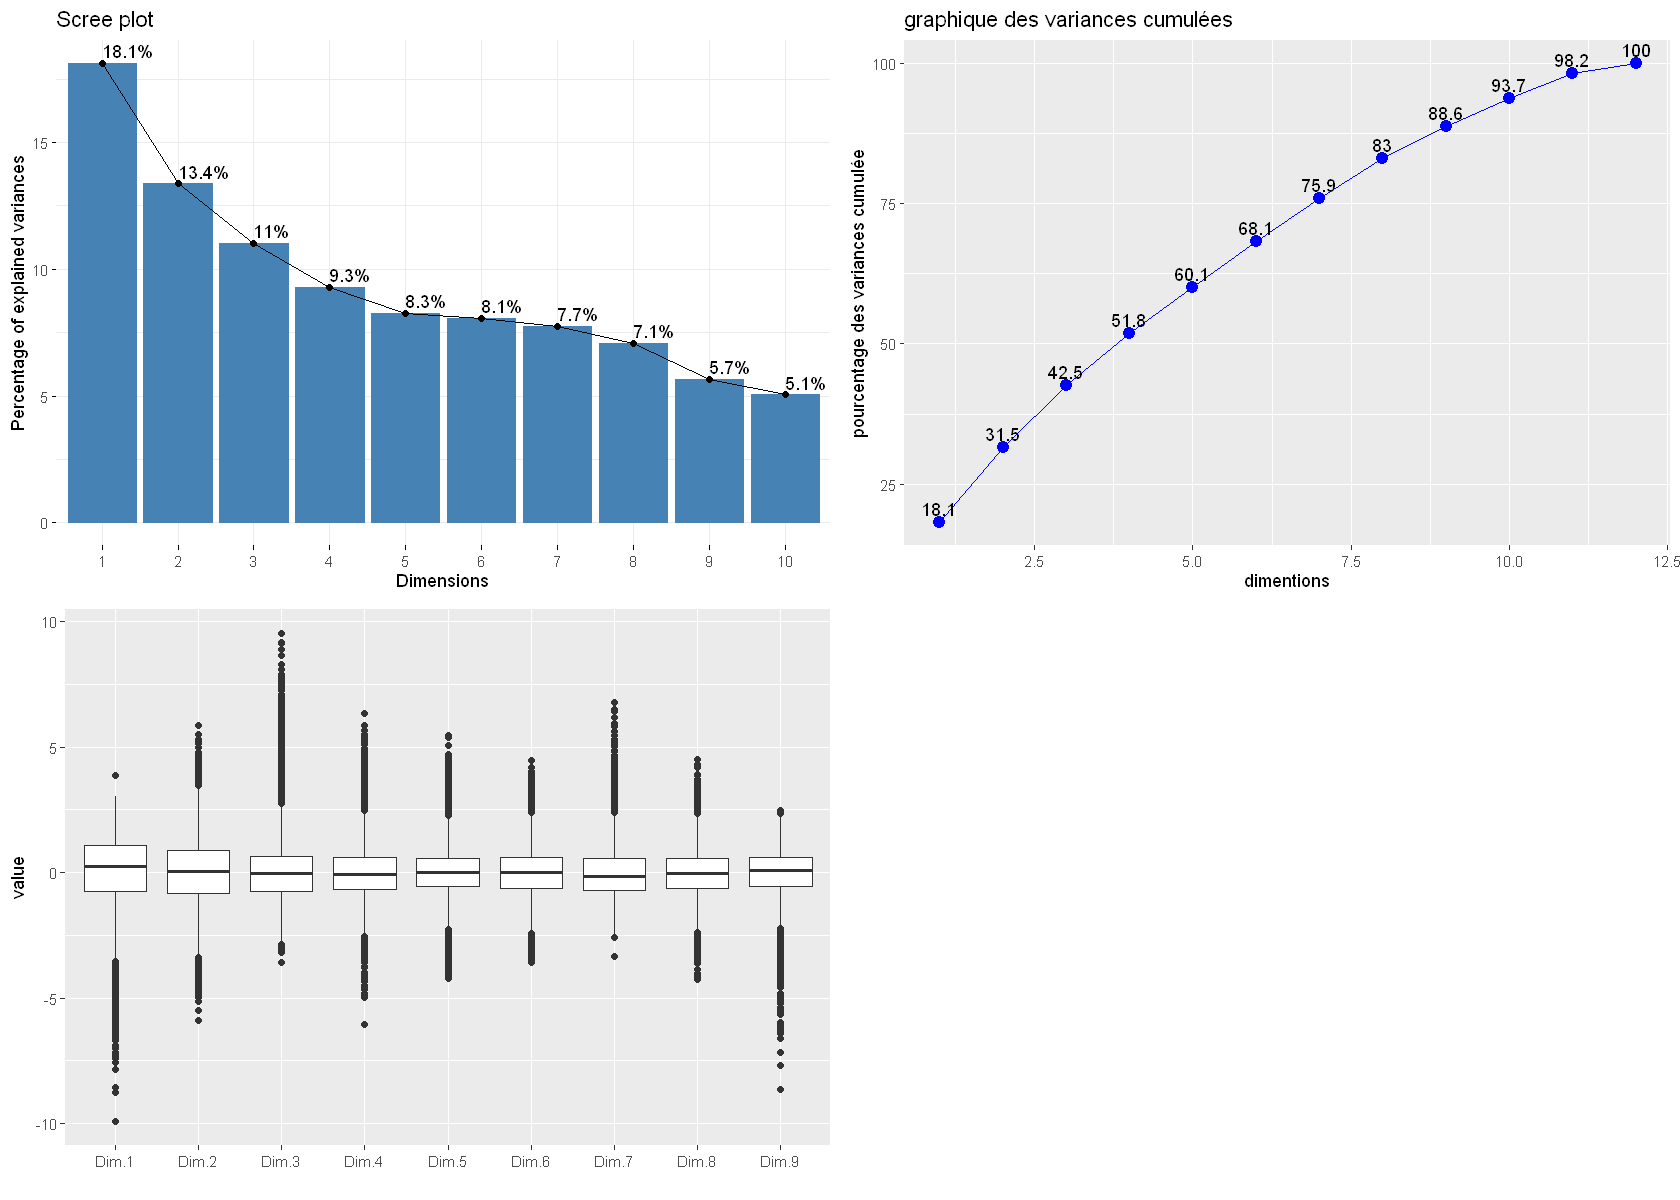

In [59]:
options(repr.plot.width=14,repr.plot.height=10)
#décroissance valeurs propres
g1<-fviz_eig(res.pca,addlabels=TRUE)

#variances cumulées
cum_var <- cumsum(res.pca$eig[,2])

# Graphique avec ggplot2
g2<-ggplot(data.frame(Dimension = 1:length(cum_var), Variance = cum_var), aes(x = Dimension, y = Variance)) +
    geom_point(size = 3, color = "blue") +
    geom_line(color = "blue") +
    labs(title = "graphique des variances cumulées",x='dimentions', y = "pourcentage des variances cumulée") +
    geom_text(aes(y = cum_var, label = round(cum_var, 1)), vjust = -0.5, color = "black") 

g3<-ggplot(melt(res.pca$ind$coord),aes(x=Var2,y=value))+
  geom_boxplot()+
  xlab("")
grid.arrange(g1,g2,g3,ncol=2)

Pour atteindre 80% de la variance, on a besoin de garder 9 composantes. Ce n'est pas très performant, la dimension n'est pas vraiment réduite.

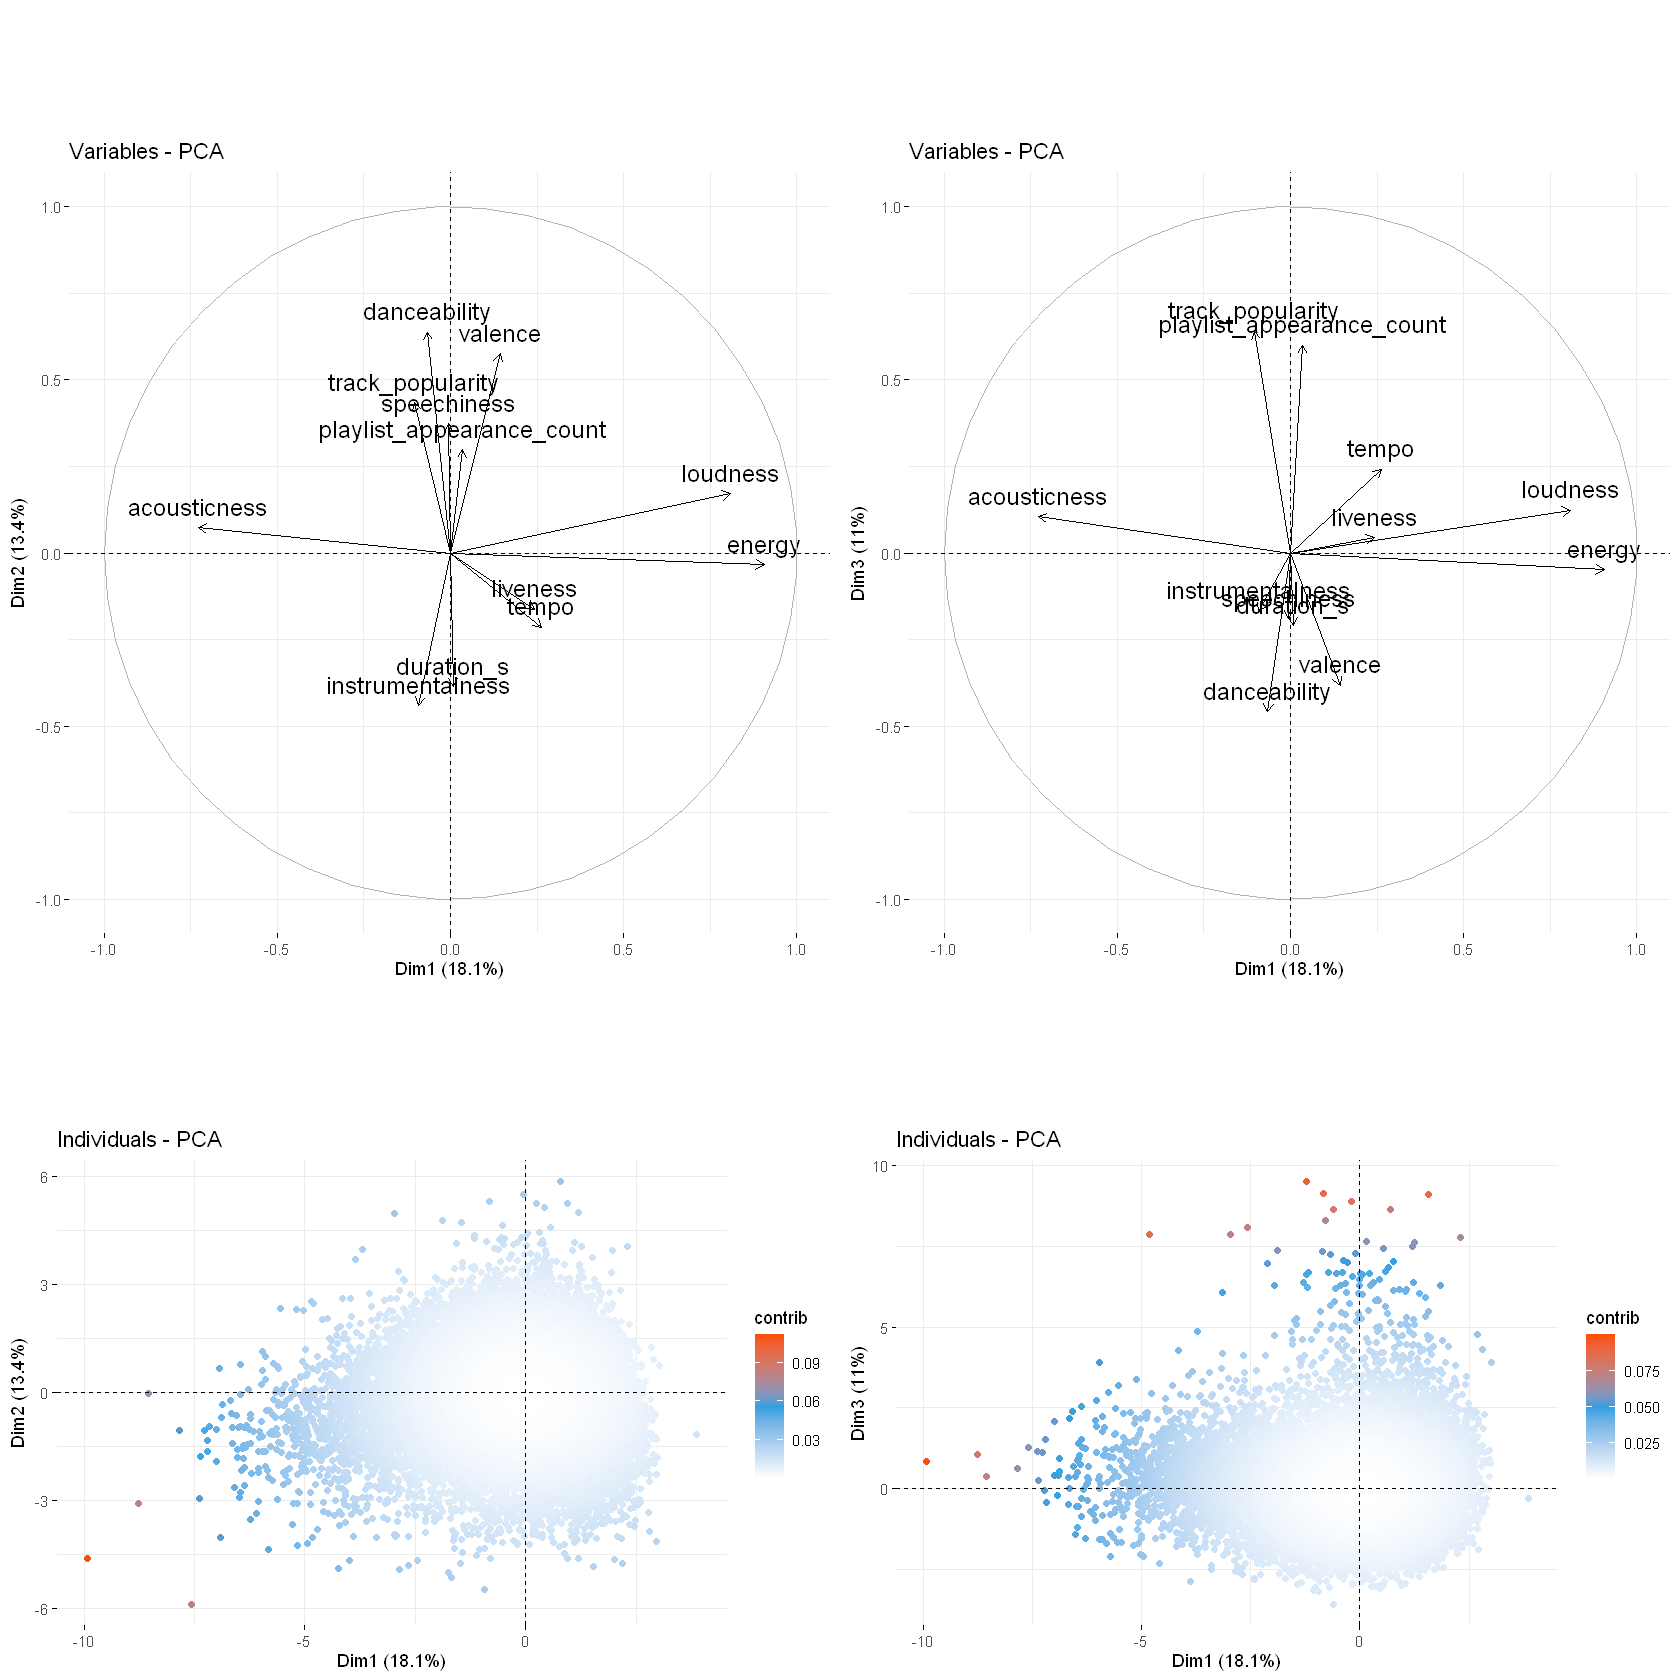

In [60]:
options(repr.plot.width=14,repr.plot.height=14)
g4<-fviz_pca_var(res.pca,labelsize = 5)
g5<-fviz_pca_ind(res.pca, col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ))
g6<-fviz_pca_var(res.pca,axes=c(1,3),labelsize = 5)
g7<-fviz_pca_ind(res.pca,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ),axes=c(1,3))

grid.arrange(g4,g6,g5,g7,ncol=2,nrow=2,heights=c(2,1))

In [61]:
contrib_ind<-res.pca$ind$contrib[,c(1,2)]
top_ind<-order(contrib_ind,decreasing=TRUE)[1:3]
song[top_ind,]

track_name,track_artist,track_popularity,track_album_name,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,⋯,acousticness,instrumentalness,liveness,valence,tempo,duration_s,month,year,playlist_appearance_count,period
<chr>,<fct>,<int>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<fct>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<int>,<fct>
Peaceful Forest,The Sleep Specialist,51,Jungle And Forest Sounds,Tropical Nights,latin,tropical,0.211,0.4250,7,⋯,0.880,6.13e-01,0.184,0.0122,116.884,181.204,1,2017,1,2010s
No Guarantee - Remix Version,Chico DeBarge,0,Long Time No See,90s R&B - The BET Planet Groove/Midnight Love Mix,r&b,new jack swing,0.220,0.0286,1,⋯,0.943,0.00e+00,0.218,0.0383,128.899,31.893,11,1997,1,1990s
Tropical Rainforest at Dawn 6,Nature Sounds,50,"Nature Sounds with Birdsong, Waves, Forest, Garden, And More Beautiful Sounds of the Earth!",Tropical Nights,latin,tropical,0.318,0.1790,8,⋯,0.877,3.82e-05,0.226,0.4220,97.368,45.000,4,2015,1,2010s


Les 3 individus qui contribuent plus que les autres dans les deux premiers plans factoriels ne sont peut-être pas des outliers mais des musiques qui sont très bien expliquées par ses plans factoriels car ce sont des musiques très spécifiques/particulières.

La première dimension sépare les musiques plutôt dynamique/énergique et les musiques plus fluides/calmes.
La seconde dimension sépare les musiques populaires/dansantes/courtes et la musique plus classique/instrumentale/longue.
La troisième dimension sépare les musiques populaires et les musiques dansantes type bal.
La quatrième dimension représente les musiques enregistrées en concert.
La cinquième dimension représente la clé de la musique.
Les 3 dernières dimensions sont difficilement interprétables.

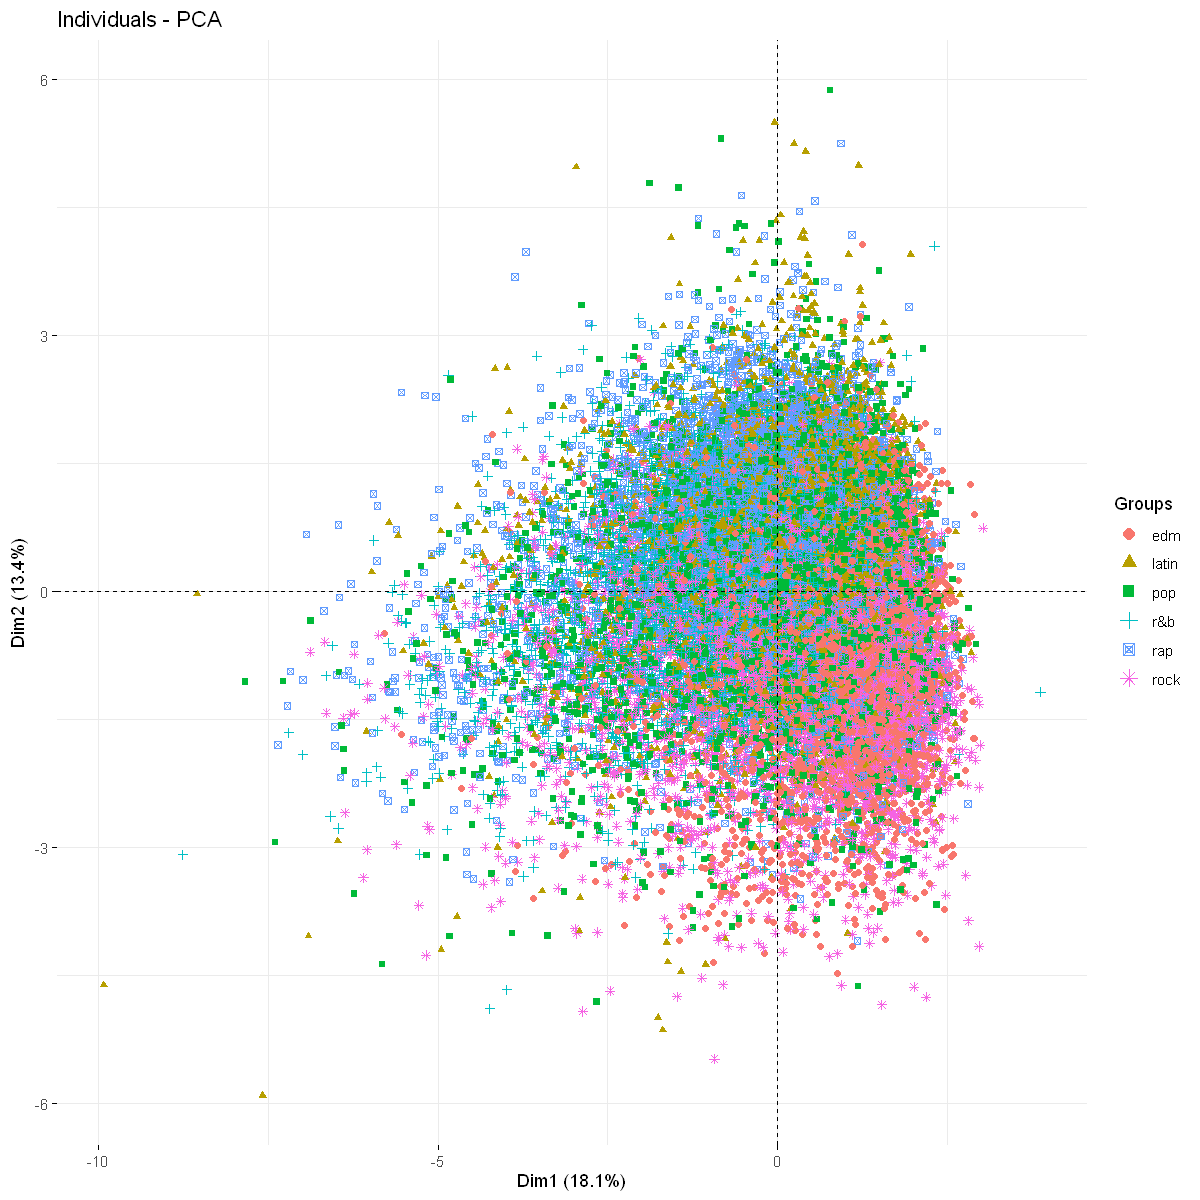

In [62]:
options(repr.plot.width=10,repr.plot.height=10)
g8<-fviz_pca_ind(res.pca, axes=c(1,2),habillage=song$playlist_genre,label="none")
g8

On voit qu'on ne peut pas discriminer facilement le genre de musique avec uniquement le premier plan factoriel.

## Clustering

### Kmeans

In [63]:
K=6
pca_coord<-res.pca$ind$coord
kmeans_pca<-kmeans(pca_coord,K,iter.max=100)
song$clusters_kmeans<-kmeans_pca$cluster
table(song$playlist_genre,song$clusters_kmeans)

       
           1    2    3    4    5    6
  edm    162 1915 1317  875  507  168
  latin  468  665  191 2210  278  416
  pop    720 1552  283 1416  269  707
  r&b   1387  615   83 1999  293  167
  rap    789  838  208 2609  521  383
  rock   792 2008  206  738  376  219

### GMM

In [ ]:
# Modèle GMM
gmm <- Mclust(projected)

# Récupérer les clusters prédits
clusters_gmm <- gmm$classification
song$clusters_gmm <- gmm$classification

# Créer un data.frame pour ggplot
df <- data.frame(
  Dim1 = pca_coord[,1],
  Dim2 = pca_coord[,2],
  cluster = as.factor(clusters_gmm)
)

# Scatterplot
ggplot(df, aes(x = Dim1, y = Dim2)) +
  geom_point(size = 1) +
  theme_minimal() +
  theme(legend.position = "right") +
  ggtitle("Gaussian Mixture Clustering (K=6)")

table(song$playlist_genre,song$clusters_gmm)

### CAH

In [ ]:
library(cluster)
library(factoextra)

# On suppose que 'projected' est ta matrice de données projetées (par exemple issue d'une MFA ou PCA)
# Calcul des distances euclidiennes
dist_matrix <- dist(pca_coord, method = "euclidean")

# Clustering hiérarchique avec méthode de Ward
hc <- hclust(dist_matrix, method = "ward.D2")

# Extraire les distances de fusion
fusion_heights <- hc$height

# Afficher les 20 dernières fusions (comme dans ton n_sizes)
n_sizes <- 20
x <- n_sizes:1
y <- tail(fusion_heights, n_sizes)

# Scatterplot des distances de fusion
plot(x, y, pch = 16,
     xlab = "Point indices",
     ylab = "Distances",
     main = "Choice of the number of classes")


In [ ]:
K=6
cah_clusters <- cutree(hc, k = K)
max_d <- (fusion_heights[length(fusion_heights) - K + 1] + 
          fusion_heights[length(fusion_heights) - K + 2]) / 2
fviz_dend(hc, cex = 0.5)
abline(h = max_d, col = "blue", lty = 2)

In [ ]:
song$cah_clusters=cah_clusters
table(song$playlist_genre,song$cah_clusters)

### Interprétation des clusters avec une MCA

Si les clusters ne correspondent pas au genre, on peut se poser la question de ce qu'ils regroupent. On va donc réaliser une MCA en discrétisant certaines des variables quantitatives pour essayer de comprendre ce que représente les clusters.

On va discrétiser les variables acousticness, energy, instrumentalness et valence qui sont des variables plutôt bien représentés dans le premier plan factoriel de l'ACP, on s'attend donc, comme les clusterings ont été réalisé sur les coordonnées d'ACP à ce que les catégories soit plutôt bien distinctes.

On va faire une MCA par méthode de clustering pour éviter que la MCA ne cherche trop à faire des correspondaces entres les clustering au lieu de chercher des correspondances avec les modalités des variables qualitatives.

In [71]:
song_MCA <- song %>%
  dplyr::select(playlist_genre)

# Ajout des variables discrétisées
song_MCA <- song_MCA %>%
  mutate(
    acousticness_class = cut(song$acousticness, 
                             breaks = c(0, 0.33, 0.66, 1), 
                             labels = c("faible", "moyen", "élevé"),
                             include.lowest = TRUE),
    
    energy_class = cut(song$energy, 
                       breaks = c(0, 0.33, 0.66, 1), 
                       labels = c("faible", "moyen", "élevé"),
                       include.lowest = TRUE),
    
    instrumentalness_class = cut(song$instrumentalness, 
                                 breaks = 3, 
                                 labels = c("faible", "moyen", "élevé"),
                                 include.lowest = TRUE),
    
    valence_class = cut(song$valence, 
                        breaks = 3, 
                        labels = c("faible", "moyen", "élevé"),
                        include.lowest = TRUE),
    
    clusters_kmeans = as.factor(song$clusters_kmeans)
  )

In [72]:
head(song_MCA)

playlist_genre,acousticness_class,energy_class,instrumentalness_class,valence_class,clusters_kmeans
<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
rock,faible,moyen,faible,moyen,1
r&b,faible,élevé,faible,élevé,2
rock,faible,élevé,faible,moyen,2
pop,faible,élevé,faible,élevé,4
pop,faible,élevé,faible,moyen,2
latin,faible,élevé,faible,élevé,4


In [75]:
res.mca = MCA(song_MCA, ncp=11,graph=FALSE)
res.mca$eig

,eigenvalue,percentage of variance,cumulative percentage of variance
dim 1,0.38524330,12.8414434,12.84144
dim 2,0.35996108,11.9987027,24.84015
dim 3,0.25550114,8.5167048,33.35685
dim 4,0.19742434,6.5808115,39.93766
dim 5,0.18947801,6.3159336,46.25360
dim 6,0.17790291,5.9300969,52.18369
dim 7,0.17292863,5.7642877,57.94798
dim 8,0.16687772,5.5625908,63.51057
dim 9,0.16145251,5.3817502,68.89232
dim 10,0.15918296,5.3060988,74.19842


Warning message:
"ggrepel: 14 unlabeled data points (too many overlaps). Consider increasing max.overlaps"
Warning message:
"ggrepel: 5 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


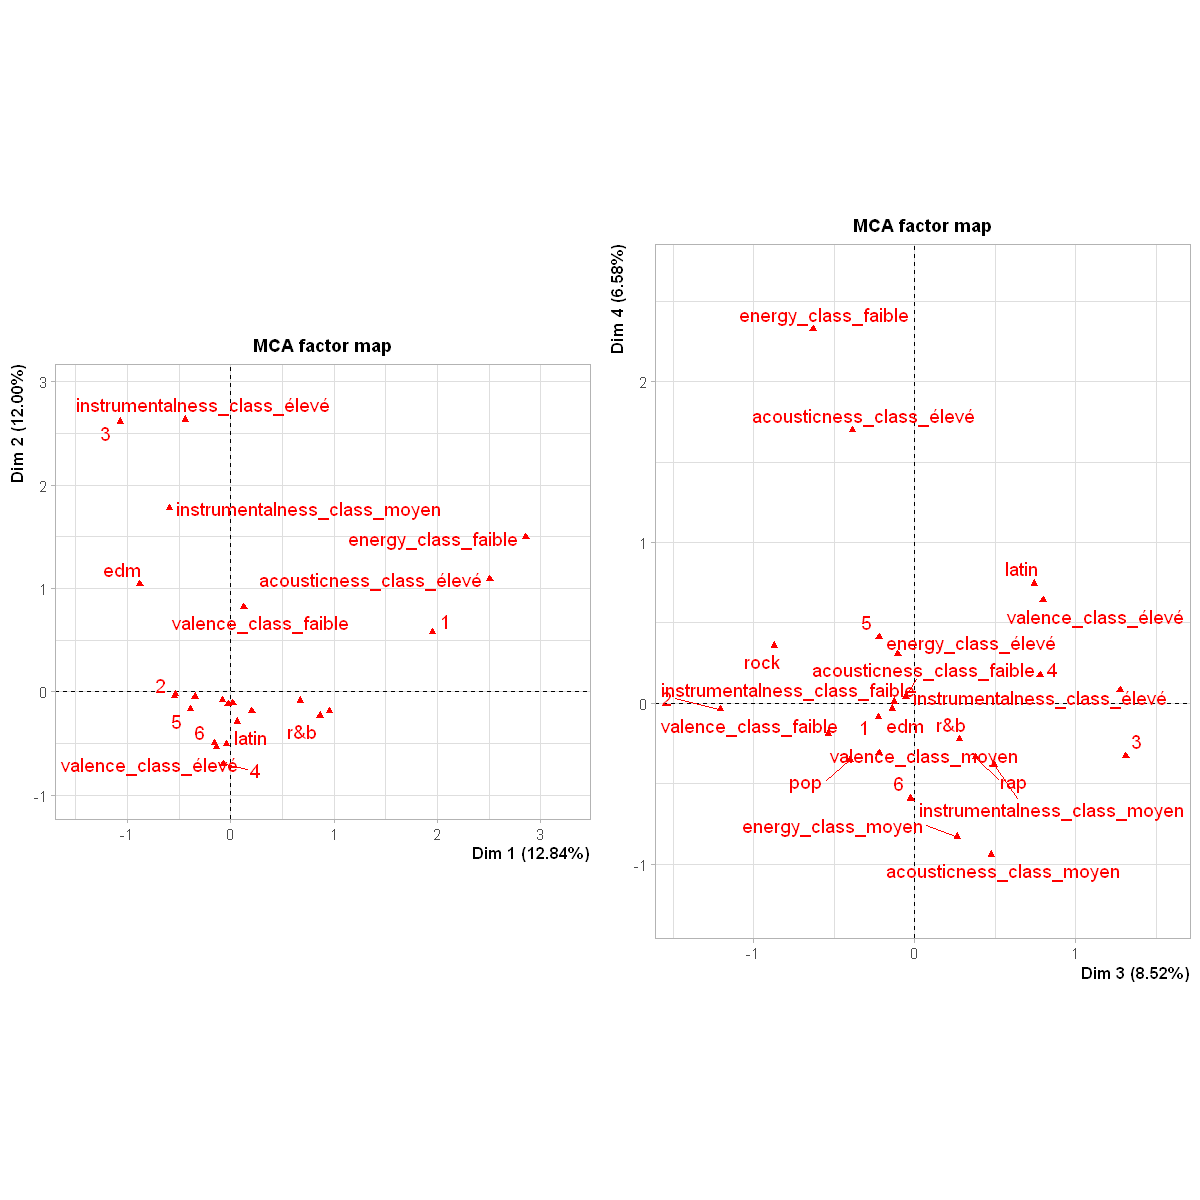

In [76]:
g1<-plot(res.mca,invisible="ind")
g2<-plot(res.mca,axes=c(3,4),invisible="ind")
grid.arrange(g1,g2,ncol=2)

Au lieu de devoir regarder chaque plan un après l'autre, (et il y en a beaucoup) pour voir les liens entre les clusters et les modalités, on peut calculer les distances à chaque modalités. Ainsi, en utilisant les coordonées de MCA de chaque modalités, on va calculer leurs distances aux coordonnées de MCA des clusters et on résume cela dans une matrice. Plus la distance est faible, plus le lien entre le cluster et la modalité est élevé.

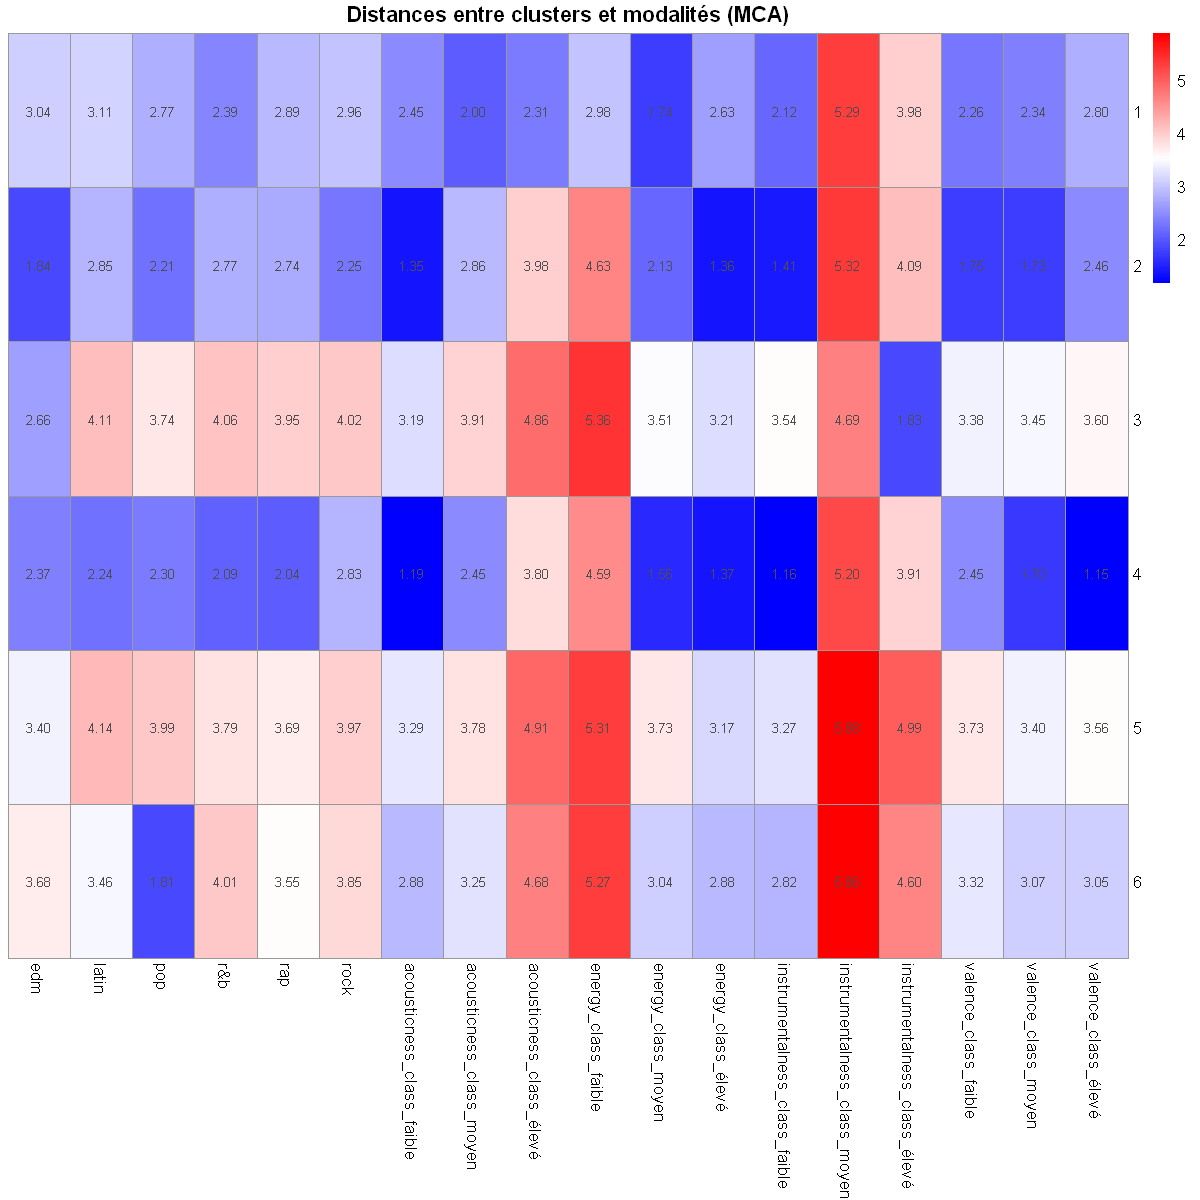

In [85]:

# coords : matrice des coordonnées des modalités (par exemple après une MCA)
coords <- res.mca$var$coord  # res.mca est l'objet MCA issu de FactoMineR::MCA()

# Séparer les modalités des clusters
clusters_coords <- coords[19:24, ]
modalities_coords <- coords[-(19:24), ]

# Calcul des distances euclidiennes entre clusters et modalités
distances <- as.matrix(dist(rbind(clusters_coords, modalities_coords)))[rownames(clusters_coords), rownames(modalities_coords)]

# Affichage heatmap avec les valeurs
pheatmap(distances, 
         cluster_rows = FALSE, 
         cluster_cols = FALSE, 
         display_numbers = TRUE, 
         color = colorRampPalette(c("blue", "white", "red"))(100),
         main = "Distances entre clusters et modalités (MCA)")



Ainsi, pour Kmeans, on en déduit que le cluster 2 est lié aux musiques edm et les musiques avec les mêmes caractéristiques que le genre edm i.e. faible acoustique, forte énergie, faible instrumentalité et une valence plutôt basse.
Le cluster 3 est lié aux musique à fort instrumentalité.
Le cluster 4 est lié au musique à faible acoustique, énergie plutot élevé, instrumentalité faible et valence plutôt élevé : les musiques qui donne la pêche, envie de bouger
Le cluster 5 est fortement lié aux musiques pop.
Les clusters 1 et 5 sont difficilement interprétables.

## LDA,QDA,KNN pour prédire le genre

## LDA

On va faire une LDA pour essayer de prédire le genre de la playlist dans laquelle se trouve la musique.

Pour facilliter la LDA, on va transformer les variables qualitatives en one-hot. On ne va pas garder que les propriétés physiques de la musique + la popularité. On va supprimer aussi le sous genre car si on ne connait pas le genre on ne connait pas le sous genre.
On va scale les données quantitatives comme pour l'ACP afin que les variables tempo et duration_s ne prennent pas trop d'importance par rapport aux autres variables qui ne prennent pas les mêmes échelles de valeurs.

In [54]:
songLDA<-subset(song, select=-track_artist)
songLDA<-subset(songLDA, select=-track_album_name)
songLDA<-subset(songLDA, select=-playlist_name)
songLDA<-subset(songLDA, select=-playlist_subgenre)
songLDA<-subset(songLDA, select=-month)
songLDA<-subset(songLDA, select=-year)
songLDA<-subset(songLDA, select=-period)
#songLDA<-subset(songLDA, select=-pop)

In [55]:
songLDA[,c(1,3:4,6,8:14)]<-scale(songLDA[,c(1,3:4,6,8:14)])
head(songLDA)

track_popularity,playlist_genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s,playlist_appearance_count
<dbl>,<fct>,<dbl>,<dbl>,<int>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
0.07024130,rock,0.19634178,-1.62048540,2,-1.0704084,1,-0.8224427,0.45691828,-0.3415404,-0.6559510,0.23731998,-0.8854632,0.14514032,1
-1.02683088,r&b,-0.48957284,0.03066611,5,0.1896227,1,-0.7141999,-0.50307365,-0.3918495,0.1350026,0.80059483,1.1094540,-0.47950192,1
-0.47829479,rock,-2.40327462,0.98975082,9,0.6846114,1,-0.6215597,-0.74273502,-0.3491083,1.0010103,-0.45397187,0.5292912,2.40560066,1
-0.64707513,pop,0.03858141,0.52110715,10,0.3865643,0,-0.5259940,-0.79182970,0.1757402,0.8406385,1.45774882,0.2627680,0.03258553,1
-0.05634395,pop,0.05915885,0.76087833,1,0.1705214,1,-0.5659756,-0.28360845,-0.3888524,-0.6597999,-0.06138637,0.3311425,0.15935088,1
-1.15341613,latin,1.25265029,0.54835388,7,0.8466437,0,-0.2012657,0.04401853,-0.3918495,-0.6347819,1.11637012,-0.9989136,-0.14606143,1


In [56]:
set.seed(42)
sample<-sample(c(TRUE,FALSE),nrow(songLDA),replace=TRUE,prob=c(0.7,0.3))
songLDA<-standardize(songLDA,exclude=c("playlist_genre","mode"))
train<-songLDA[sample,]
test<-songLDA[!sample,]


res.lda<-lda(playlist_genre~.,data=train)

In [57]:
lda_pred<-predict(res.lda,test)

In [58]:
conf_matrix <- confusionMatrix(lda_pred$class, factor(test$playlist_genre))
print(conf_matrix)

Registered S3 methods overwritten by 'proxy':
  method               from    
  print.registry_field registry
  print.registry_entry registry



Confusion Matrix and Statistics

          Reference
Prediction edm latin pop r&b rap rock
     edm   839   145 188  48 152   99
     latin 141   437 205 167 159   63
     pop   242   227 527 175 134  154
     r&b    66   147 186 509 167  141
     rap   127   217 127 293 905   18
     rock   79   105 240 175  66  823

Overall Statistics
                                         
               Accuracy : 0.4757         
                 95% CI : (0.465, 0.4864)
    No Information Rate : 0.1864         
    P-Value [Acc > NIR] : < 2.2e-16      
                                         
                  Kappa : 0.3699         
                                         
 Mcnemar's Test P-Value : < 2.2e-16      

Statistics by Class:

                     Class: edm Class: latin Class: pop Class: r&b Class: rap
Sensitivity             0.56158      0.34194    0.35777    0.37235     0.5717
Specificity             0.90970      0.89813    0.86724    0.90079     0.8868
Pos Pred Value          0.

On obtient une précision de 47% sur la classification ce qui n'est pas très bon.

Essayer QDA, LDA sur espace d'ACP

Pas fou

## QDA

In [62]:
res.qda<-qda(playlist_genre~.,data=train)

In [63]:
qda_pred<-predict(res.qda,test)

In [64]:
conf_matrix <- confusionMatrix(qda_pred$class, factor(test$playlist_genre))
print(conf_matrix)

Confusion Matrix and Statistics

          Reference
Prediction edm latin pop r&b rap rock
     edm   984   164 276  59 121   91
     latin  45   234  75  57  94   23
     pop   160   256 460 144 123  123
     r&b   102   317 289 722 410  158
     rap    97   157  92 204 773   42
     rock  106   150 281 181  62  861

Overall Statistics
                                          
               Accuracy : 0.475           
                 95% CI : (0.4643, 0.4857)
    No Information Rate : 0.1864          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.3692          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       

Statistics by Class:

                     Class: edm Class: latin Class: pop Class: r&b Class: rap
Sensitivity              0.6586      0.18310    0.31229    0.52816    0.48831
Specificity              0.8984      0.95925    0.88519    0.82094    0.91433
Pos Pred Value   

> On remarque que l'on atteint environ 50% de précision, ce qui est visiblement meilleur que la LDA/LDA dans l'espace d'ACP. Cependant, il serait souhaitable d'avoir de meilleurs résultats.

## kNN

In [65]:
knn_genre<-train(playlist_genre~.,data=train,method="knn",trControl=trainControl(method="cv"),tuneGrid=data.frame(k=seq(10,30)))

In [66]:
knn_genre

k-Nearest Neighbors 

19859 samples
   14 predictor
    6 classes: 'edm', 'latin', 'pop', 'r&b', 'rap', 'rock' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 17872, 17873, 17873, 17874, 17872, 17873, ... 
Resampling results across tuning parameters:

  k   Accuracy   Kappa    
  10  0.4926719  0.3900166
  11  0.4971034  0.3952695
  12  0.5020391  0.4012190
  13  0.5018364  0.4009198
  14  0.5039013  0.4034091
  15  0.5051093  0.4048232
  16  0.5048585  0.4044801
  17  0.5064695  0.4064749
  18  0.5083327  0.4086708
  19  0.5083328  0.4086176
  20  0.5100447  0.4107250
  21  0.5084328  0.4087633
  22  0.5092884  0.4098264
  23  0.5088857  0.4093129
  24  0.5106981  0.4114302
  25  0.5118063  0.4127435
  26  0.5105484  0.4112182
  27  0.5116054  0.4124788
  28  0.5117066  0.4125804
  29  0.5131167  0.4142688
  30  0.5131668  0.4143273

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was k = 30.

In [68]:
best_knn<-knn3(playlist_genre~.,data=train,k=knn_genre$bestTune$k)
pred_genre<-predict(best_knn,test,type="class")
conf_matrix <- confusionMatrix(pred_genre, factor(test$playlist_genre))
print(conf_matrix)

Confusion Matrix and Statistics

          Reference
Prediction  edm latin  pop  r&b  rap rock
     edm   1003   140  263   60  119  106
     latin   88   472  146  150  157   52
     pop    196   272  582  194  159  197
     r&b     56   133  201  569  167  153
     rap     89   191  113  276  937   22
     rock    62    70  168  118   44  768

Overall Statistics
                                          
               Accuracy : 0.5099          
                 95% CI : (0.4993, 0.5206)
    No Information Rate : 0.1864          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.4105          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       

Statistics by Class:

                     Class: edm Class: latin Class: pop Class: r&b Class: rap
Sensitivity              0.6714      0.36933    0.39511     0.4162     0.5919
Specificity              0.9017      0.91781    0.85499     0.9004 

A nouveau environ 51% de précision ce qui n'est toujours pas satisfaisant.

## CA

#### Nous transformons la variable quantitative `track_popularity` en variable qualitative, afin de l'utiliser dans une CA sur elle et la variable `playlist_genre `. Pour vérifier l'indépendance,on utilise un test du $\chi^2$.

In [24]:
song$track_popularity_quali <- as.factor(floor((song$track_popularity)/10))

In [70]:
table_genre_popu<-table(song$playlist_genre,song$track_popularity_quali)

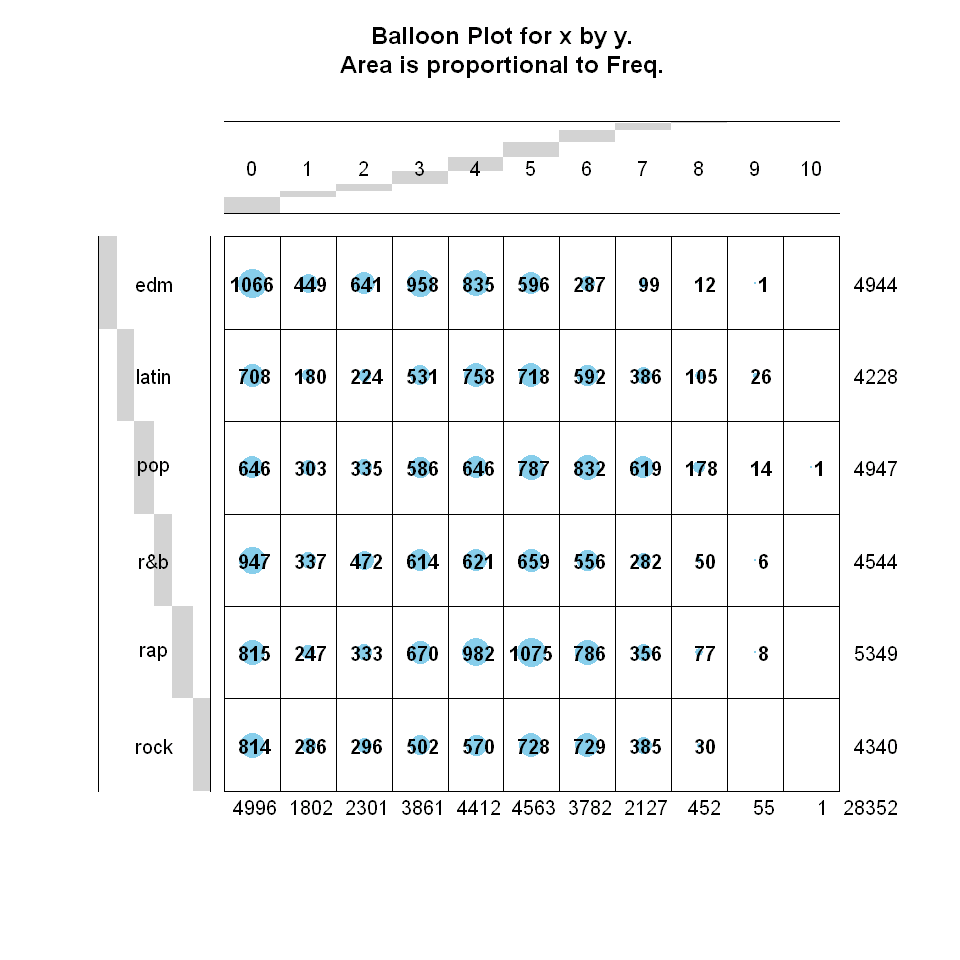

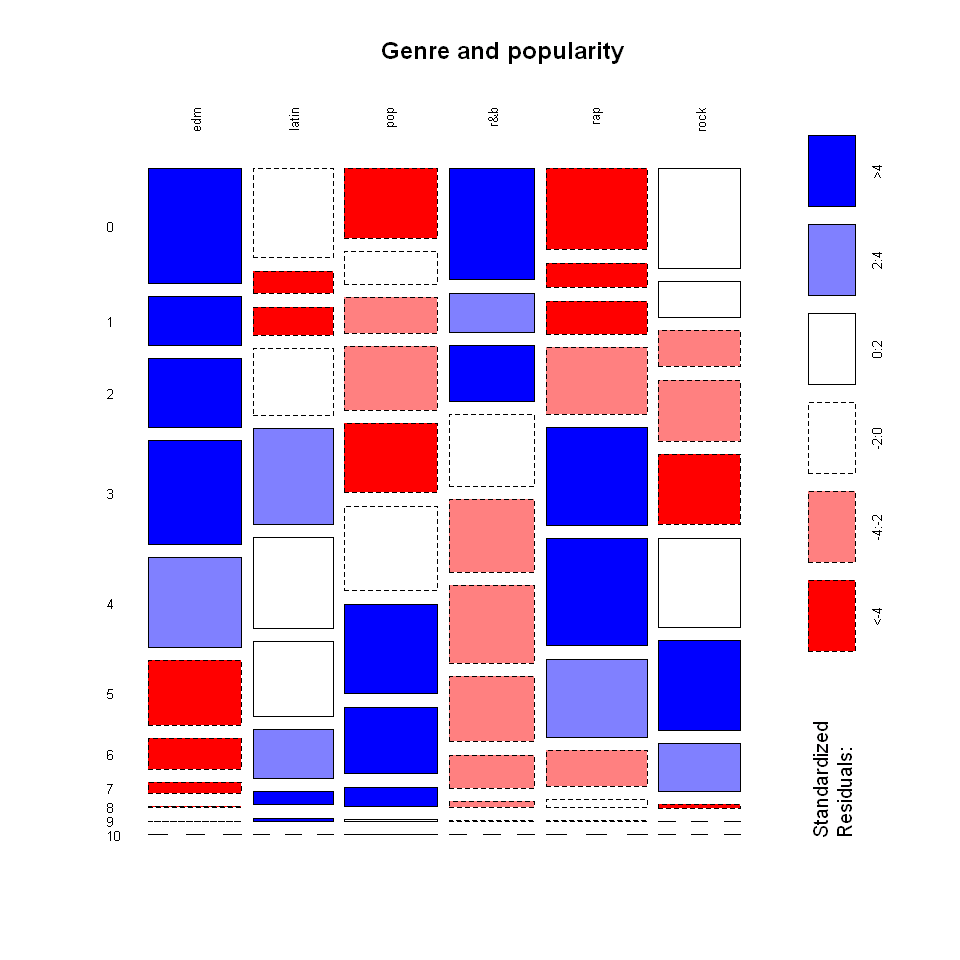

In [71]:
options(repr.plot.width=8,repr.plot.height=8)
balloonplot(t(table_genre_popu))
mosaicplot(table_genre_popu, shade = TRUE, las=2, main = "Genre and popularity")

> On observe qu'il y a très peu de sons populaires et les dépendances entres facteurs ne sont pas flagrantes. Nous allons mainteneant réalisé un test du $\chi^2$ pour voir si il y a indépendance et si la CA est utile ou non.

In [72]:
chisq.test(table_genre_popu)

Warning message in chisq.test(table_genre_popu):
"L’approximation du Chi-2 est peut-être incorrecte"



	Pearson's Chi-squared test

data:  table_genre_popu
X-squared = 1899.5, df = 50, p-value < 2.2e-16


> La p-valeur est inférieur au niveau de confiance 5%, on rejette donc l'hypothèse d'indépendance à se niveau de confiance. On va donc pouvoir faire une CA pour trouver ces dépendances.

In [73]:
res.ca = CA(table_genre_popu, graph=FALSE)

In [74]:
res.ca$eig

,eigenvalue,percentage of variance,cumulative percentage of variance
dim 1,0.0500324148,74.6799433,74.67994
dim 2,0.0086957153,12.9794959,87.65944
dim 3,0.0060852510,9.0830355,96.74247
dim 4,0.0017372014,2.5930010,99.33548
dim 5,0.0004452033,0.6645244,100.00000


> On voit qu'avec 2 dimensions on conserve plus de 90% de la variance ce qui est très satisfaisant. On va maintenant plot les facteurs dans le premier plan de CA.

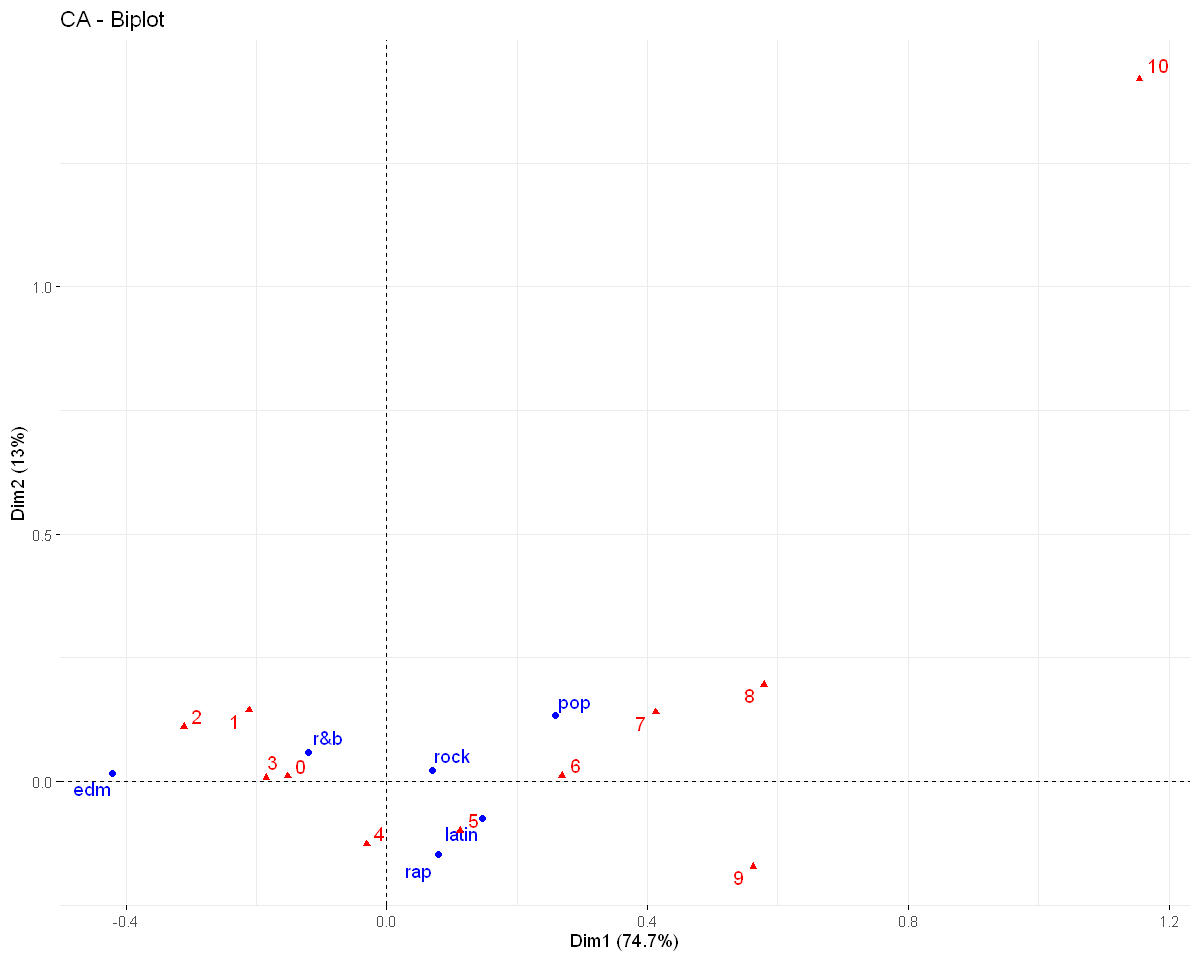

In [109]:
options(repr.plot.width=10,repr.plot.height=8)
fviz_ca_biplot(res.ca, repel=TRUE)

> On observe un lien entre les genre `edm`, `r&b` et les faibles popularités. On observe également un lien entre `rock`,`rap`,`latin` et les popularités moyennes. De mêmen `pop` a un lien avec les hautes popularité.
> On interprète cela comme le fait que le genre `pop` est un genre assez général, que tout le monde peut écouter assez souvent et aimer. Au contraire, les genres `edm` et `r&b` sont plus niches et ont une communauté plutôt restreinte. Les 3 derniers sont des genres avec des communautés plus importantes mais on ne peut pas forcément écouter ces musiques avec tout le monde et/ou dans toutes les situations.

## MCA

Pour étudier un impact potentiel du tempo dans certains intervalles, on va créer une variable `tempo_quali` de la même manière que la popularité dans la CA.

To do : ajouter les clusters pour essayer de les interpréter 

In [16]:
song <- song %>%
  mutate(
    tempo_quali = case_when(
      tempo < 40   ~ "Larghissimo",
      tempo < 60   ~ "Largo",
      tempo < 80   ~ "Adagio",
      tempo < 100  ~ "Andante",
      tempo < 120  ~ "Allegretto",
      tempo < 140  ~ "Vivace",
      tempo < 188  ~ "Presto",
      TRUE         ~ "Prestissimo"
    ),
    tempo_quali = as.factor(tempo_quali)
  )


In [21]:
head(song)

track_name,track_artist,track_popularity,track_album_name,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,⋯,instrumentalness,liveness,valence,tempo,duration_s,month,year,playlist_appearance_count,period,tempo_quali
<chr>,<fct>,<int>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<fct>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<int>,<fct>,<fct>
Pangarap,Barbie's Cradle,41,Trip,Pinoy Classic Rock,rock,classic rock,0.682,0.401,2,⋯,0.011700,0.0887,0.566,97.091,235.440,1,2001,1,2000s,Andante
The Others,RIKA,15,The Others,Groovy // Funky // Neo-Soul,r&b,neo soul,0.582,0.704,5,⋯,0.000000,0.2120,0.698,150.863,197.286,1,2018,1,2010s,Presto
I Feel Alive,Steady Rollin,28,Love & Loss,Hard Rock Workout,rock,hard rock,0.303,0.880,9,⋯,0.009940,0.3470,0.404,135.225,373.512,11,2017,1,2010s,Vivace
Liquid Blue,The.madpix.project,24,Liquid Blue,Electropop - Pop,pop,electropop,0.659,0.794,10,⋯,0.132000,0.3220,0.852,128.041,228.565,8,2015,1,2010s,Vivace
Fever,YOSA & TAAR,38,Fever,Best of 2019 Dance Pop: Japan,pop,dance pop,0.662,0.838,1,⋯,0.000697,0.0881,0.496,129.884,236.308,11,2018,1,2010s,Vivace
No Me Acuerdo,Thalía,12,No Me Acuerdo,latin hip hop,latin,latin hip hop,0.836,0.799,7,⋯,0.000000,0.0920,0.772,94.033,217.653,6,2018,1,2010s,Andante


In [35]:
song_quali<- song[c(6,23,24,25)]

In [36]:
head(song_quali)

playlist_genre,period,tempo_quali,track_popularity_quali
<fct>,<fct>,<fct>,<fct>
rock,2000s,Andante,4
r&b,2010s,Presto,1
rock,2010s,Vivace,2
pop,2010s,Vivace,2
pop,2010s,Vivace,3
latin,2010s,Andante,1


In [39]:
res.mca = MCA(song_quali, ncp=21,graph=FALSE)


In [40]:
summary(res.mca)


Call:
MCA(X = song_quali, ncp = 21, graph = FALSE) 


Eigenvalues
                       Dim.1   Dim.2   Dim.3   Dim.4   Dim.5   Dim.6   Dim.7
Variance               0.418   0.365   0.320   0.300   0.288   0.268   0.260
% of var.              5.964   5.217   4.565   4.290   4.115   3.830   3.719
Cumulative % of var.   5.964  11.181  15.746  20.036  24.151  27.981  31.700
                       Dim.8   Dim.9  Dim.10  Dim.11  Dim.12  Dim.13  Dim.14
Variance               0.256   0.255   0.254   0.252   0.251   0.250   0.250
% of var.              3.655   3.637   3.629   3.596   3.589   3.575   3.567
Cumulative % of var.  35.356  38.993  42.622  46.218  49.807  53.381  56.948
                      Dim.15  Dim.16  Dim.17  Dim.18  Dim.19  Dim.20  Dim.21
Variance               0.249   0.249   0.248   0.247   0.244   0.243   0.234
% of var.              3.561   3.556   3.546   3.531   3.479   3.468   3.345
Cumulative % of var.  60.510  64.066  67.611  71.143  74.622  78.089  81.435
         

Warning message:
"ggrepel: 20 unlabeled data points (too many overlaps). Consider increasing max.overlaps"
Warning message:
"ggrepel: 20 unlabeled data points (too many overlaps). Consider increasing max.overlaps"
Warning message:
"ggrepel: 28 unlabeled data points (too many overlaps). Consider increasing max.overlaps"
Warning message:
"ggrepel: 29 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


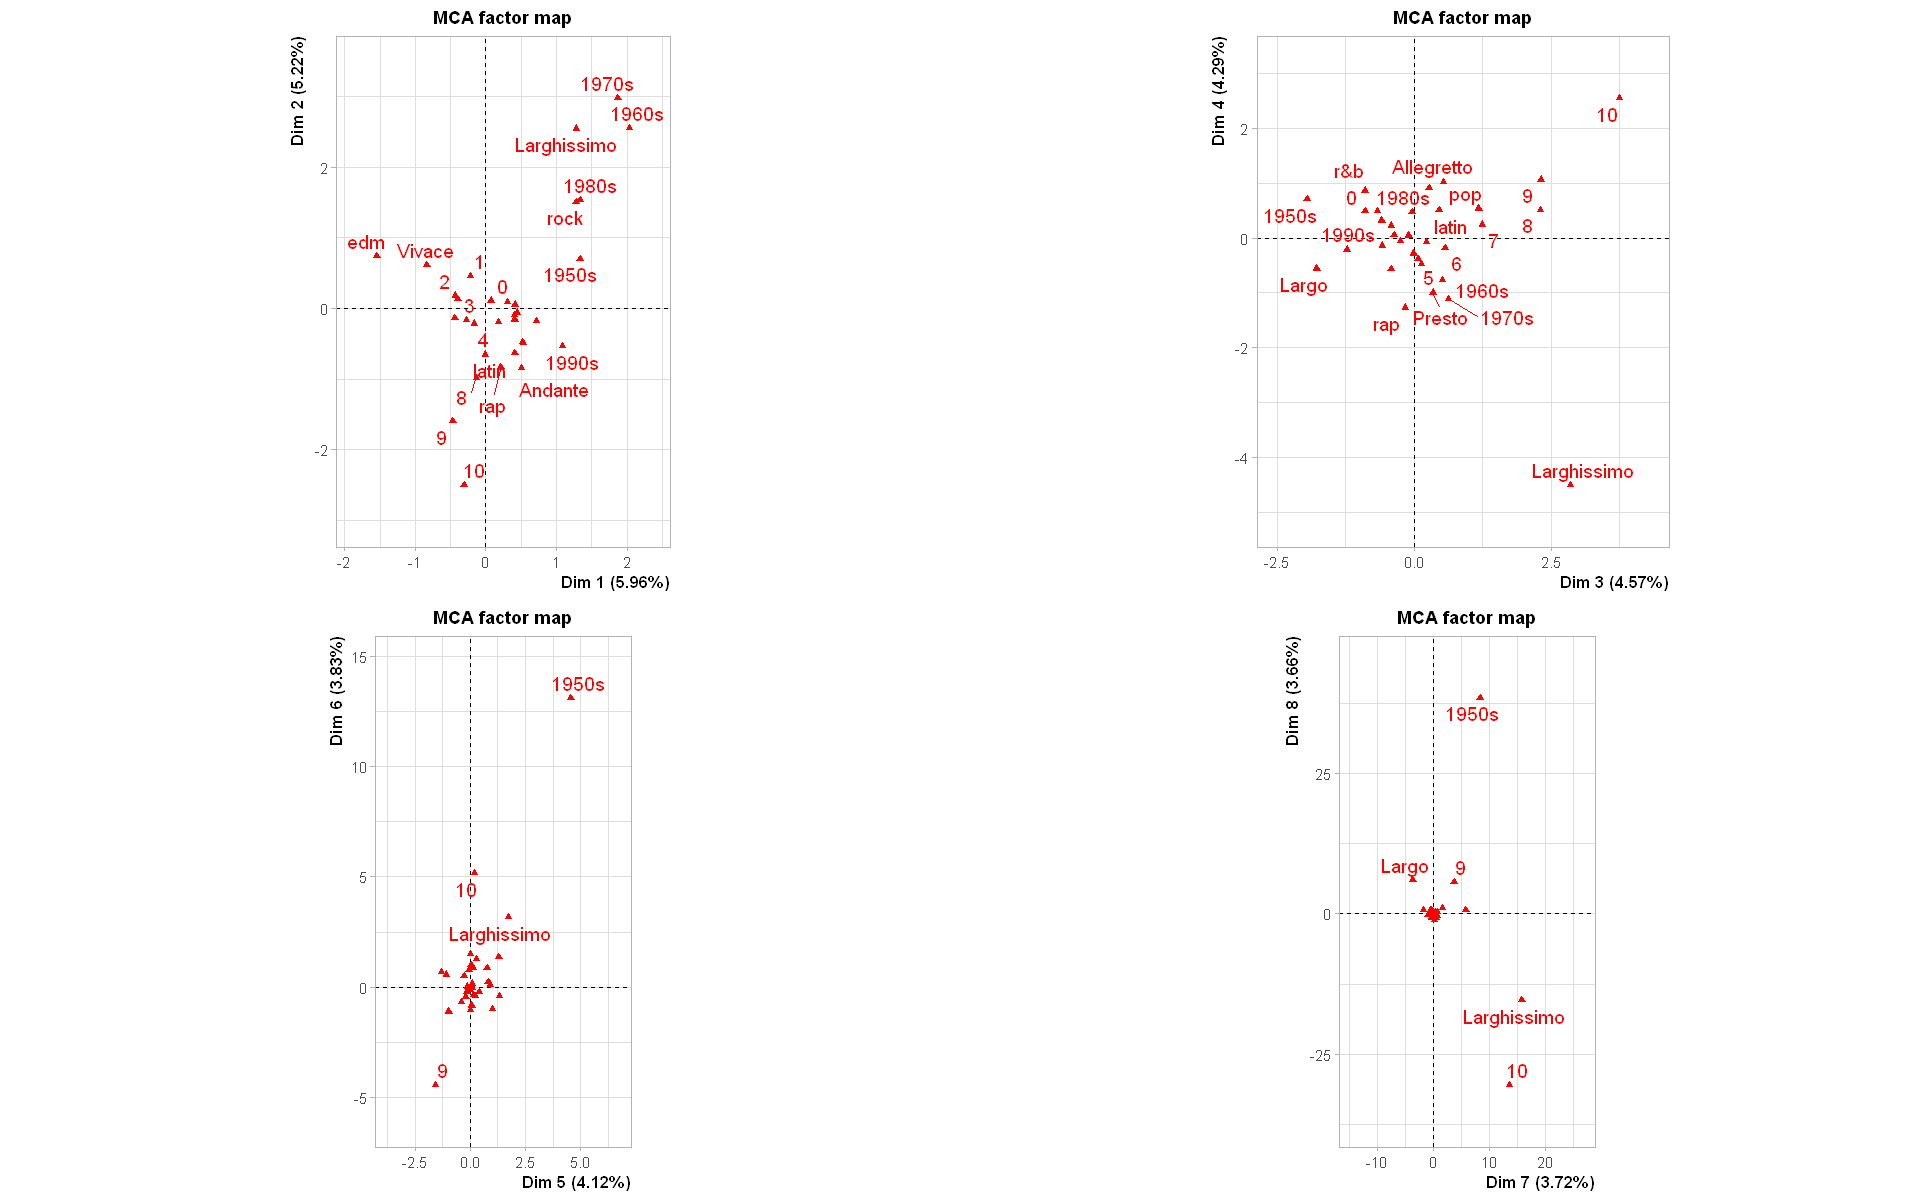

In [41]:
g1<-plot(res.mca,invisible="ind")
g2<-plot(res.mca,axes=c(3,4),invisible="ind")
g3<-plot(res.mca,axes=c(5,6),invisible="ind")
g4<-plot(res.mca,axes=c(7,8),invisible="ind")
options(repr.plot.width=16,repr.plot.height=10)
grid.arrange(g1,g2,g3,g4,ncol=2)

- **Dimension 1** : Genres edm et rock, années 2010, tempo vivace (120-140)
- **Dimension 2** : Rock des années 70
- **Dimension 3** : Pop des années 90 avec un tempo allegretto (100-120)
- **Dimension 4** : Rap et R&B tempo presto (140-188)
- **Dimension 5** : Latin des années 2000 à très faible popularité, tempo adagio (60-80)

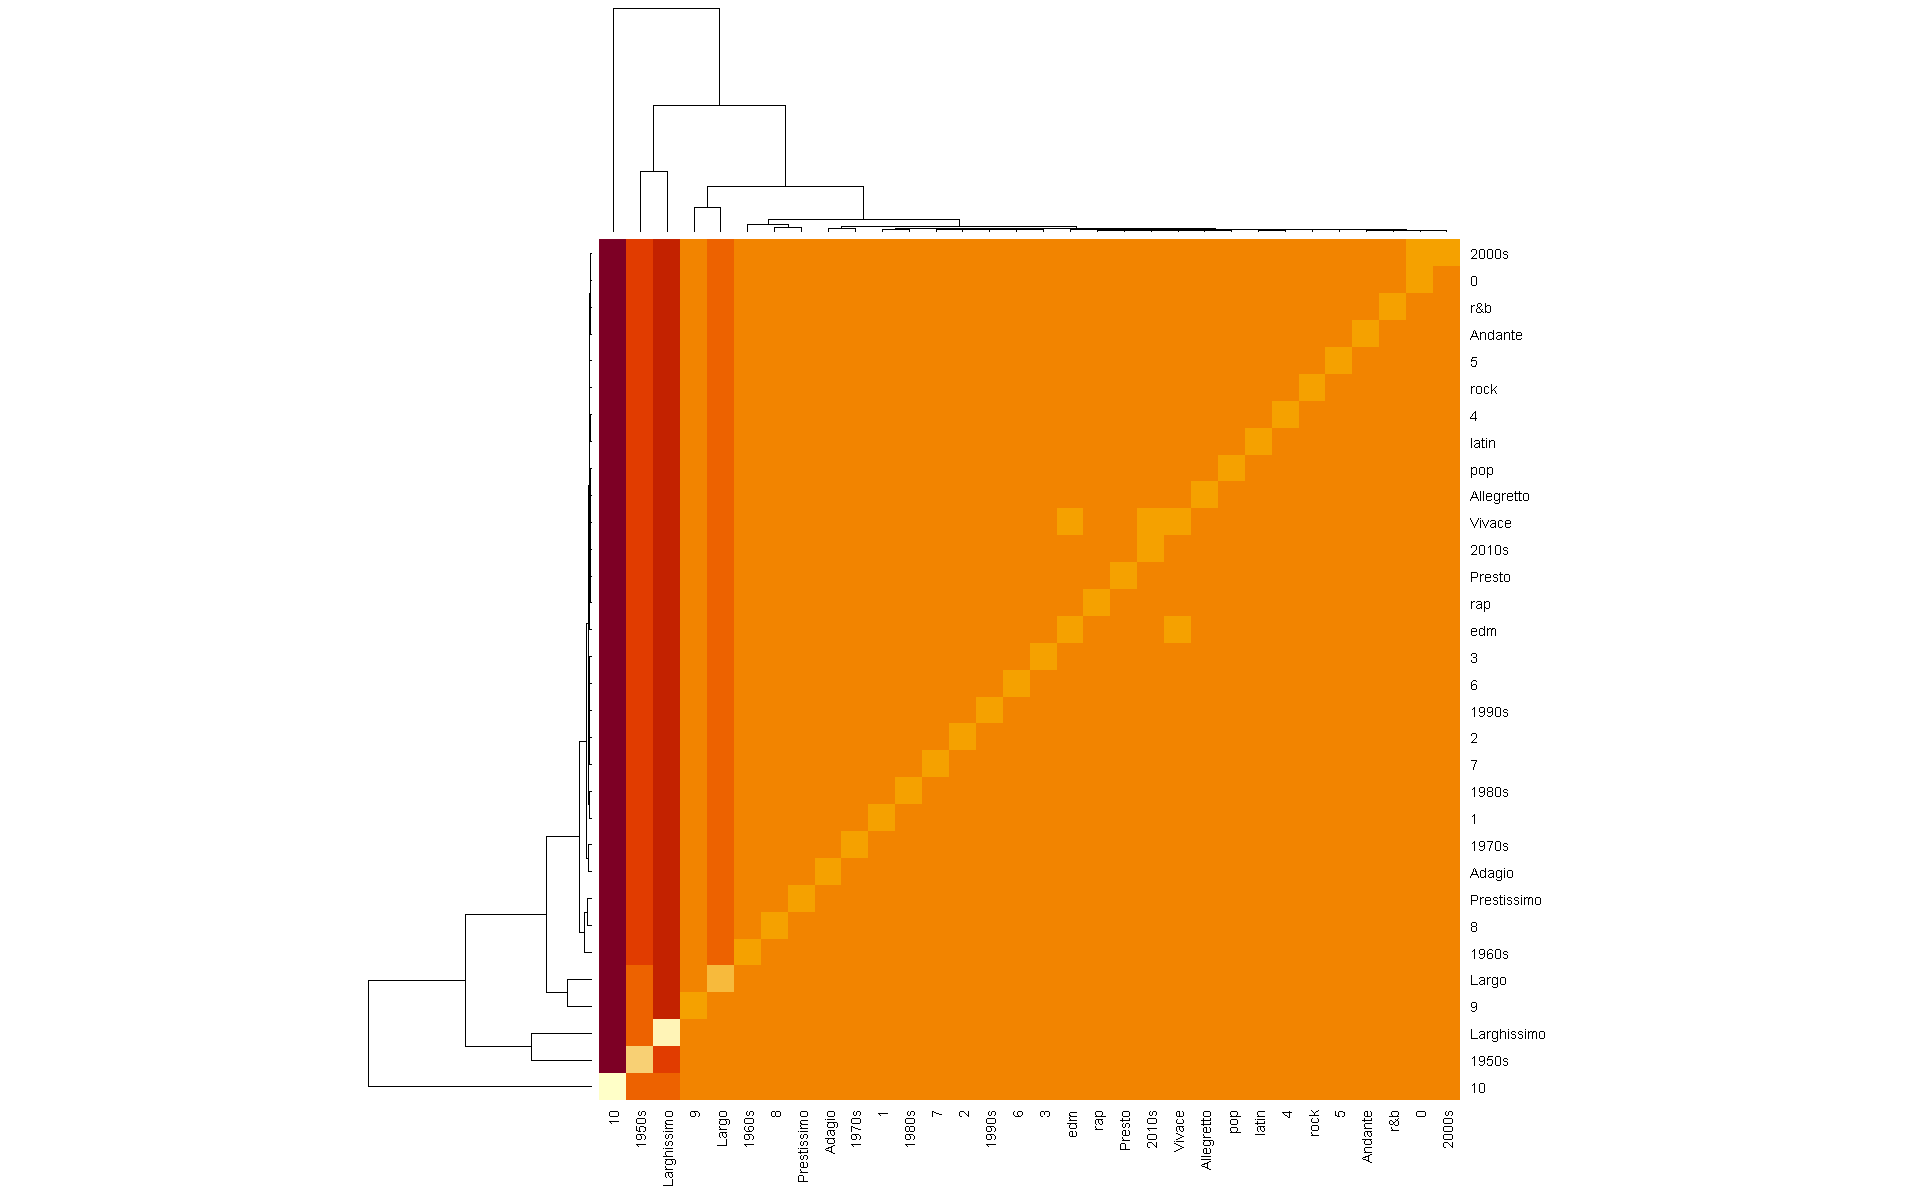

In [42]:
# Coordonnées des modalités
coords <- res.mca$var$coord

# Calcul des distances euclidiennes entre modalités
dist_matrix <- dist(coords)

# Afficher sous forme de matrice
dist_matrix<-as.matrix(dist_matrix)
heatmap(dist_matrix)

## Retrouver la décennie d'un titre en fonction de ses caractéristiques physiques : possible?

In [111]:
head(song)

track_artist,track_popularity,track_album_name,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,⋯,liveness,valence,tempo,duration_s,month,year,playlist_appearance_count,period,track_popularity_quali,tempo_quali
<fct>,<int>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<int>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>
Barbie's Cradle,41,Trip,Pinoy Classic Rock,rock,classic rock,0.682,0.401,2,-10.068,⋯,0.0887,0.566,97.091,235.440,1,2001,1,2000s,4,Andante
RIKA,15,The Others,Groovy // Funky // Neo-Soul,r&b,neo soul,0.582,0.704,5,-6.242,⋯,0.2120,0.698,150.863,197.286,1,2018,1,2010s,1,Presto
Steady Rollin,28,Love & Loss,Hard Rock Workout,rock,hard rock,0.303,0.880,9,-4.739,⋯,0.3470,0.404,135.225,373.512,11,2017,1,2010s,2,Vivace
The.madpix.project,24,Liquid Blue,Electropop - Pop,pop,electropop,0.659,0.794,10,-5.644,⋯,0.3220,0.852,128.041,228.565,8,2015,1,2010s,2,Vivace
YOSA & TAAR,38,Fever,Best of 2019 Dance Pop: Japan,pop,dance pop,0.662,0.838,1,-6.300,⋯,0.0881,0.496,129.884,236.308,11,2018,1,2010s,3,Vivace
Thalía,12,No Me Acuerdo,latin hip hop,latin,latin hip hop,0.836,0.799,7,-4.247,⋯,0.0920,0.772,94.033,217.653,6,2018,1,2010s,1,Andante


In [112]:
song_dec<-song[c(7:18)]
song_dec$key<-as.factor(song_dec$key)
head(song_dec)

danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s
<dbl>,<dbl>,<fct>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.682,0.401,2,-10.068,1,0.0236,0.279000,0.011700,0.0887,0.566,97.091,235.440
0.582,0.704,5,-6.242,1,0.0347,0.065100,0.000000,0.2120,0.698,150.863,197.286
0.303,0.880,9,-4.739,1,0.0442,0.011700,0.009940,0.3470,0.404,135.225,373.512
0.659,0.794,10,-5.644,0,0.0540,0.000761,0.132000,0.3220,0.852,128.041,228.565
0.662,0.838,1,-6.300,1,0.0499,0.114000,0.000697,0.0881,0.496,129.884,236.308
0.836,0.799,7,-4.247,0,0.0873,0.187000,0.000000,0.0920,0.772,94.033,217.653


In [113]:
groupes <-list(
    physique = c("danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence"),
    musique = c("key", "mode"),
    tempo = c("tempo"),
    durée = c("duration_s"))
    #période = c("period"))
ordre_col <- unlist(groupes)
song_dec_ord <- song_dec[, ordre_col]
res.mfa_dec <- MFA(song_dec_ord, group = c( 8, 2, 1, 1), ncp=8,type = c("s", "n", "s", "s"), name.group = c("physique", "musique", "tempo", "durée"),graph=FALSE)


In [114]:
data_mfa_dec<-as.data.frame(res.mfa_dec$ind$coord)
data_mfa_dec$period<-song$period
train<-data_mfa_dec[sample,]
test<-data_mfa_dec[!sample,]
real_dec<-test$period
test<-subset(test,select=-period)

In [115]:
head(train)

,Dim.1,Dim.2,Dim.3,Dim.4,Dim.5,Dim.6,Dim.7,Dim.8,period
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
3,1.6511481,2.58235927,0.5829974,0.04491146,0.8728646,-0.1972170,0.4982622,0.1498707,2010s
5,0.6216620,0.04789276,-0.8212837,0.66847984,1.1031028,1.0647508,-0.5701293,-0.1414493,2010s
6,-0.6364353,-0.40392203,0.1479532,1.42678798,-0.3635314,-0.0124419,0.2213454,0.8028872,2010s
8,-1.7173201,0.80218216,0.1795217,0.68996127,0.4688264,-0.9370357,0.9957249,-1.3635532,1990s
9,-0.3212849,0.35050617,0.2249036,0.69324590,-0.8601714,-1.0348101,-0.9189357,1.7314120,1980s
11,0.2655428,-0.24155295,-0.9842956,0.37862569,-0.3026264,0.1598937,1.0297416,1.1556823,2010s


In [117]:
library(nnet)
model_multinom <- multinom(period ~ ., data = train)

# weights:  70 (54 variable)
initial  value 38643.829650 
iter  10 value 19720.508531
iter  20 value 19197.010958
iter  30 value 18757.351737
iter  40 value 18611.014388
iter  50 value 18503.753605
iter  60 value 18426.683447
iter  70 value 18417.064880
final  value 18416.127393 
converged


In [118]:
# Prédictions
preds <- predict(model_multinom, newdata = test)

In [119]:
t<-table(preds,real_dec)
print(t)
print(sum(diag(t))/sum(t))

       real_dec
preds   1950s 1960s 1970s 1980s 1990s 2000s 2010s
  1950s     0     0     0     0     0     0     0
  1960s     0     0     0     0     0     0     0
  1970s     0     1     0     0     0     0     2
  1980s     0     2     2     3     2     3     6
  1990s     0     0     6     5     6     6    40
  2000s     0     1     3     7     3     7    32
  2010s     1    54   222   338   636  1208  5897
[1] 0.6962204


On obtient une précision pas trop mauvaise (74%) mais cela est dû aux musiques des années 2010 omniprésentes dans le jeu de données. Notre algorithme a tendance a prédire 2010s à tout bout de champs car c'est une des manières les plus sûres d'avoir juste. Si on regardais la précision uniquement sur les autres décennies, le résultat serait catastrophique.

In [120]:
song_dec<-song[song$period!="2010s",]
per<-song_dec$period
song_dec<-song_dec[c(7:18)]
song_dec$key<-as.factor(song_dec$key)
song_dec_ord <- song_dec[, ordre_col]
res.mfa_dec2 <- MFA(song_dec_ord, group = c( 8, 2, 1, 1), ncp=8,type = c("s", "n", "s", "s"), name.group = c("physique", "musique", "tempo", "durée"),graph=FALSE)
data_mfa_dec2<-as.data.frame(res.mfa_dec2$ind$coord)
data_mfa_dec2$period<-per
sample<-sample(c(TRUE,FALSE),nrow(song_dec),replace=TRUE,prob=c(0.7,0.3))
train<-data_mfa_dec2[sample,]
test<-data_mfa_dec2[!sample,]
real_dec<-test$period
test<-subset(test,select=-period)
model_multinom2 <- multinom(period ~ ., data = train)
preds2 <- predict(model_multinom2, newdata = test)
t<-table(preds2,real_dec)
print(t)
print(sum(diag(t))/sum(t))

Warning message in multinom(period ~ ., data = train):
"le groupe '2010s' est vide"


# weights:  60 (45 variable)
initial  value 10544.504476 
iter  10 value 7618.420049
iter  20 value 7405.874555
iter  30 value 7272.967439
iter  40 value 7183.492489
iter  50 value 7106.319673
iter  60 value 7102.700538
iter  70 value 7102.346469
final  value 7102.345351 
converged
       real_dec
preds2  1950s 1960s 1970s 1980s 1990s 2000s 2010s
  1950s     0     0     0     0     0     0     0
  1960s     0     0     1     0     0     0     0
  1970s     1     5    16     8    19    31     0
  1980s     0     4    13    13    10    19     0
  1990s     0     2    15    24    48    45     0
  2000s     2    49   206   280   606  1152     0
[1] 0.4783963


En enlevant les musiques de 2010, un nouveau modèle donne 50% de précision ce qui est assez faible malgré une grosse amélioration de la prédiction des autres décennies que pour le modèle précédent.


## Comprendre le lien entre popularité et composantes de la musique

### Avec NMF

In [121]:
song_nmf<-subset(songLDA, select=-c(mode,playlist_genre,track_popularity))

In [122]:
song_nmf_scaled <-as.data.frame(lapply(song_nmf,rescale))
song_nmf_matrix<-as.matrix(song_nmf_scaled)

In [123]:
n_components=5
nmf_result<-nmf(song_nmf_matrix,rank=n_components,seed=42)
W<-basis(nmf_result)
H<-coef(nmf_result)

In [124]:
H

danceability,energy,key,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s,playlist_appearance_count
0.11612985,0.1201634768,1.207761e+00,0.1697748,5.382131e-03,3.372718e-05,2.220446e-16,4.600445e-04,0.043041074,0.09112355,0.0958572,2.220446e-16
0.51419736,0.4721059556,2.220446e-16,0.4991215,8.720830e-02,5.955996e-04,2.220446e-16,2.919497e-03,0.692147285,0.28521869,0.2438544,2.220446e-16
0.06176517,0.0550234425,2.220446e-16,0.0501652,2.220446e-16,7.417005e-05,3.180360e-01,3.070796e-07,0.003167906,0.04012568,0.0415505,2.220446e-16
0.34965032,0.5888093174,2.220446e-16,0.6184699,7.825723e-02,2.220446e-16,2.220446e-16,3.112639e-01,0.018136837,0.39743977,0.3264324,2.220446e-16
0.16620256,0.0003816898,2.220446e-16,0.1980425,3.677287e-02,4.428832e-01,2.220446e-16,5.473081e-02,0.056356187,0.12813341,0.1073962,4.368731e-02


- **Composante 1** : musique instrumentale
- **Composante 2** : clé du morceau (plus ou moins aigu/grave)
- **Composante 3** : les musiques forte ,qui pulsent, qui t'attaque (pas calme), musique de concert
- **Composante 4**: les musiques de la boom (entrainante,ce qui donne envie de faire la fête et de bouger) 
- **Composante 5** : musique acoustique (vrai instrument, pas électronique)

In [125]:
W_df<-as.data.frame(W)
colnames(W_df)<-paste0("factor_",1:ncol(W_df))
W_df$popularity<-song$track_popularity
correlations<-cor(W_df)
print(correlations["popularity",])

    factor_1     factor_2     factor_3     factor_4     factor_5   popularity 
-0.007683349  0.026090276 -0.128022001 -0.105169394  0.162542525  1.000000000 


On observe une très légère corrélation négative entre la popularité et la 1ère composante latente qui correspond uniquement à l'instrumentalité. Ce résultat ne nous apporte pas beaucoup d'informations car avec la matrice de corrélations de base, on possédait déjà cette valeur de corrélation.

Si on veut faire une chanson qui a du succès, nos résultats suggèrent de faire une musique entraînante, avec beaucoup de parties vocales, assez calme (pas agressive), avec de vrais instruments; Néanmoins, les corrélations sont très faibles, il n'y a donc pas de recette magique pour produire une chanson à succès et on peut supposer que la popularité d'une chanson dépend davantage de l'artiste qui la sort que de ses propriétés physiques...

## MFA puis regression linéaire pour popularité

In [126]:
song_mfa<-subset(song, select=-c(track_popularity, track_album_name, playlist_name, month, year))
song_mfa$key<-as.factor(song_mfa$key)

In [127]:
head(song_mfa)

track_artist,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s,playlist_appearance_count,period,track_popularity_quali,tempo_quali
<fct>,<fct>,<fct>,<dbl>,<dbl>,<fct>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<fct>,<fct>,<fct>
Barbie's Cradle,rock,classic rock,0.682,0.401,2,-10.068,1,0.0236,0.279000,0.011700,0.0887,0.566,97.091,235.440,1,2000s,4,Andante
RIKA,r&b,neo soul,0.582,0.704,5,-6.242,1,0.0347,0.065100,0.000000,0.2120,0.698,150.863,197.286,1,2010s,1,Presto
Steady Rollin,rock,hard rock,0.303,0.880,9,-4.739,1,0.0442,0.011700,0.009940,0.3470,0.404,135.225,373.512,1,2010s,2,Vivace
The.madpix.project,pop,electropop,0.659,0.794,10,-5.644,0,0.0540,0.000761,0.132000,0.3220,0.852,128.041,228.565,1,2010s,2,Vivace
YOSA & TAAR,pop,dance pop,0.662,0.838,1,-6.300,1,0.0499,0.114000,0.000697,0.0881,0.496,129.884,236.308,1,2010s,3,Vivace
Thalía,latin,latin hip hop,0.836,0.799,7,-4.247,0,0.0873,0.187000,0.000000,0.0920,0.772,94.033,217.653,1,2010s,1,Andante


On choisit les groupes de façon suivante, sachant qu'ils doivent être homogènes:
- artiste
- genre et sous-genre
- caractéristiques physiques calculées par Spotify (danceability, speechiness, ...) dont les méthodes de calcul ne sont pas connues
- caractéristiques musicales (variables key et mode)
- tempo
- durée
- période
- nombre de présence dans les playlists

In [128]:
groupes <-list(
    genre = c("playlist_genre", "playlist_subgenre"),
    physique = c("danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence"),
    musique = c("key", "mode"),
    tempo = c("tempo"),
    durée = c("duration_s"),
    période = c("period"),
    nb_playlist =c("playlist_appearance_count"))
ordre_col <- unlist(groupes)
song_mfa_ord <- song_mfa[, ordre_col]
res.mfa <- MFA(song_mfa_ord, group = c( 2, 8, 2, 1, 1, 1,1), ncp=7,type = c("n", "s", "n", "s", "s", "n","s"), name.group = c("genre", "physique", "musique", "tempo", "durée", "période","nb_playlist"),graph=FALSE)

In [129]:
data_mfa<-as.data.frame(res.mfa$ind$coord)
data_mfa$popularity<-song$track_popularity

In [130]:
head(data_mfa)

,Dim.1,Dim.2,Dim.3,Dim.4,Dim.5,Dim.6,Dim.7,popularity
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,2.3885864,-0.1367199,-0.62792583,0.748152627,0.5611850,-1.4078577,0.1422641,41
2,-0.1130374,-0.2080989,-0.06506237,-0.629614726,-0.6780654,-0.9032277,1.0035997,15
3,1.8989245,2.1754053,1.01467971,-0.008055095,0.1076293,-0.1436861,0.4089168,28
4,-0.6684548,0.3236605,0.20822290,0.578217499,-0.7541825,0.3893548,0.9433533,24
5,-0.7075288,0.6224873,-0.42391337,0.645590842,-0.5415454,0.9695178,0.9639382,38
6,-0.7746185,-0.6537086,0.16179583,1.421895056,-0.3525466,-0.9997425,-1.7250534,12


In [131]:
sample<-sample(c(TRUE,FALSE),nrow(data_mfa),replace=TRUE,prob=c(0.7,0.3))
train<-data_mfa[sample,]
test<-data_mfa[!sample,]

In [132]:
lm.mfa<-lm(popularity~.,data=train)

In [133]:
summary(lm.mfa)


Call:
lm(formula = popularity ~ ., data = train)

Residuals:
   Min     1Q Median     3Q    Max 
-61.78 -16.59   3.30  16.95  53.28 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 39.1579104  0.1551584 252.374  < 2e-16 ***
Dim.1       -1.2598195  0.1123891 -11.209  < 2e-16 ***
Dim.2       -0.3444149  0.1230519  -2.799 0.005132 ** 
Dim.3       -6.0050792  0.1349543 -44.497  < 2e-16 ***
Dim.4        2.6088150  0.1416712  18.415  < 2e-16 ***
Dim.5        0.5208451  0.1434551   3.631 0.000283 ***
Dim.6        4.3877720  0.1479569  29.656  < 2e-16 ***
Dim.7        0.0005356  0.1646081   0.003 0.997404    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 21.88 on 19876 degrees of freedom
Multiple R-squared:  0.1436,	Adjusted R-squared:  0.1433 
F-statistic: 476.3 on 7 and 19876 DF,  p-value: < 2.2e-16


In [134]:
pred.pop<-predict(lm.mfa,test)

In [135]:
sum(abs(pred.pop-test$popularity))/length(pred.pop)

[1] 18.32317

In [136]:
lm.mfa_intonly<-lm(popularity~1,data=train)
pred.pop_intonly<-predict(lm.mfa_intonly,test)
sum(abs(pred.pop_intonly-test$popularity))/length(pred.pop_intonly)

[1] 20.13199

Pas très efficace, on a une MAE à peine plus faible que pour le modèle intercept only qui estime par la popularité moyenne.